## Getting Dtw distance matrix

In [1]:
#import neccessary data
import numpy as np
import pickle
from dtaidistance import clustering, dtw_ndim, dtw
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


try:
    with open('operationList.pkl', 'rb') as f:
        operations = pickle.load(f)
except:
    print("Error")


In [2]:
distMatrix = dtw_ndim.distance_matrix(operations, ndim=57)


## Running Tsne

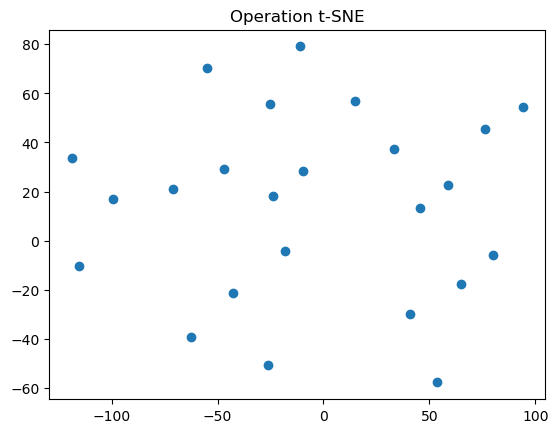

In [3]:
embedded = TSNE(n_components=2, metric='precomputed', random_state=42, init='random', perplexity = 5).fit_transform(distMatrix)


# plot
plt.scatter(embedded[:, 0], embedded[:, 1])
plt.title("Operation t-SNE")
plt.show()

Data isnt showing any clusters clearly but since we dont procedure labels its hard to really tell whats going on

## Hiearchical clustering

In [4]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage 

condensedDist = squareform(distMatrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix

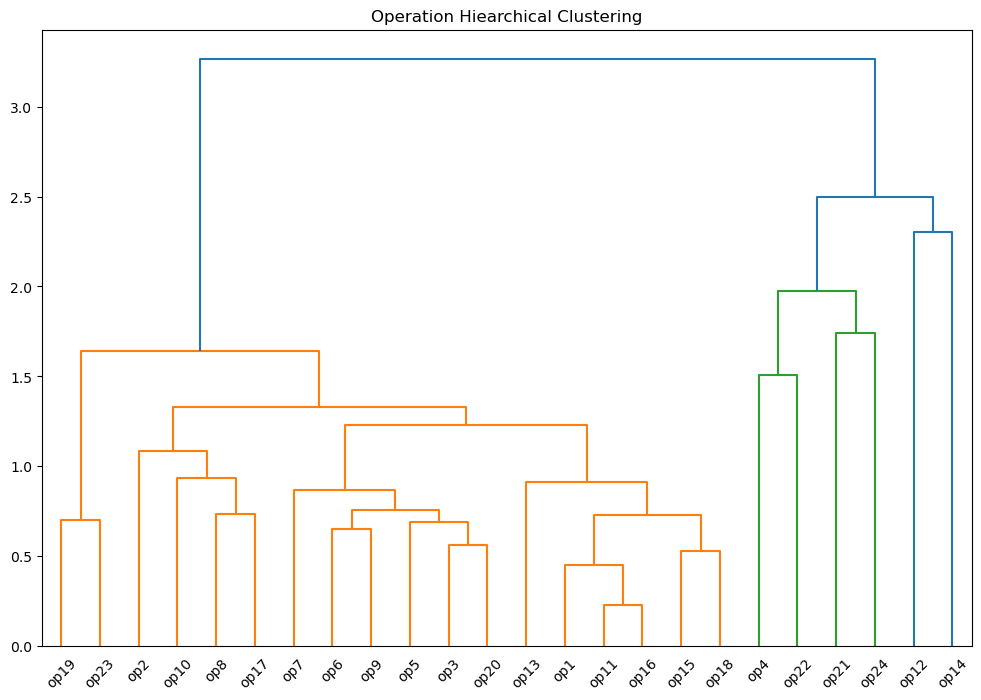

In [5]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

opLabels = [f"op{i}" for i in range(1, 25)]

plt.figure(figsize=(12, 8))

dendrogram(x, labels = opLabels)
plt.title("Operation Hiearchical Clustering")
plt.show()

Observations:
- 3 main clusters: 
    - Seems to be clustered based on op length (in terms of frames)
    - Orange cluster far larger containing 19/24 operations, suggesting that green and blue clusters may be outliers
    - Blue frame len avg: 101 , Green frame len avg: 49,   compared to global avg of 24 frames

Will try dtw again with sakoe chiba band to see if that changes results

In [6]:
x_Chiba1 = clustering.LinkageTree(dtw_ndim.distance_matrix_fast, 
                                dists_options={"ndim": 57, "window": 5}).fit(operations) #tight constraint

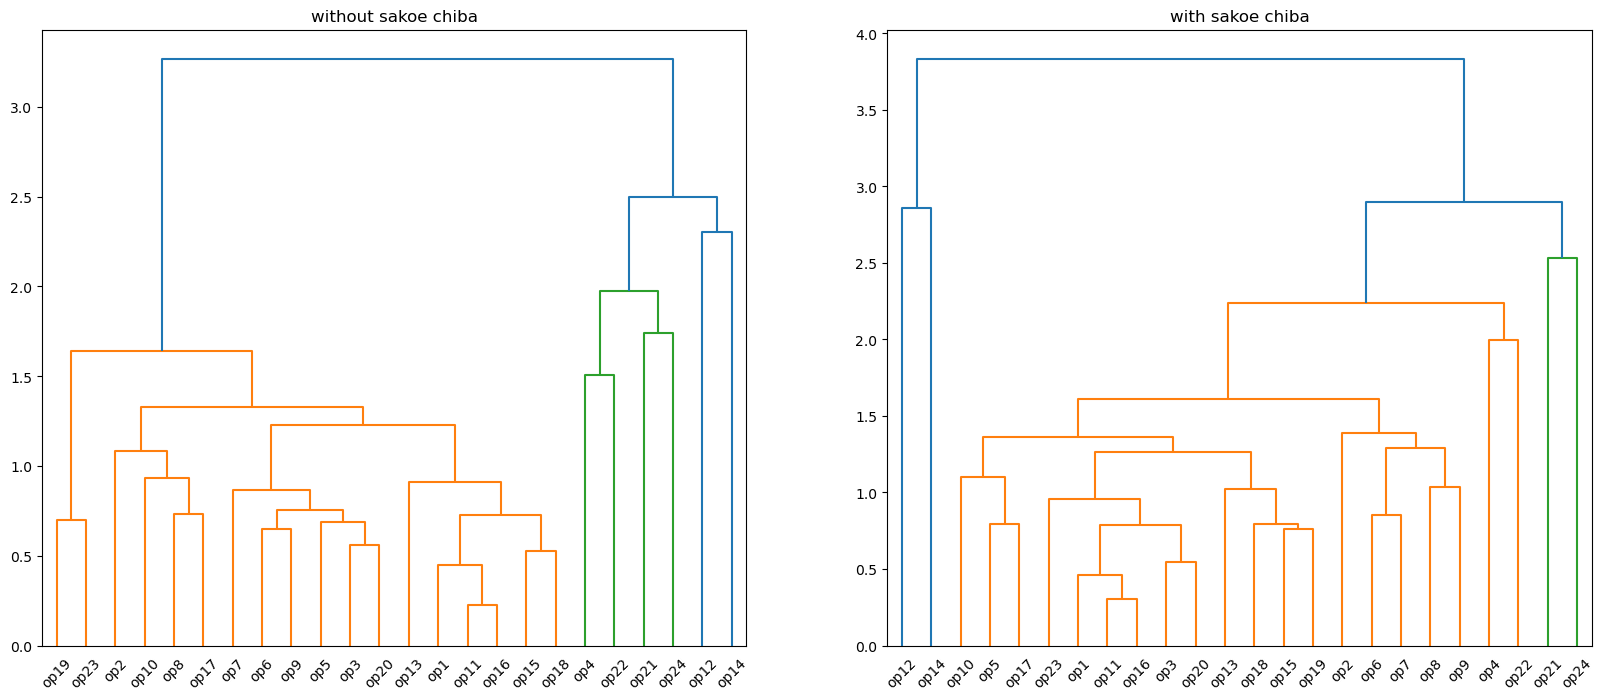

In [7]:
##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x,  ax = ax1, labels = opLabels)
dendrogram(x_Chiba1, ax = ax2, labels = opLabels)

ax1.set_title("without sakoe chiba")
ax2.set_title("with sakoe chiba")

plt.show()



Adding sakoe chiba didnt help much due to the vast difference between largest and smallest frame. Will normalize dtw weights to see if that provides better results

### Retrying with DTW normalization

In [8]:
#seq = list of timesseries <-- operations
#returns normalized distance matrix
def n_dtw(seq, window = None):
    N = len(seq)
    distMatrix = np.zeros((N,N))

    for i in range(N):
        for j in range(i+1, N):
            dist, paths = dtw_ndim.warping_paths(seq[i], seq[j], window = window)
            pathLen = len(dtw.best_path(paths))
            normalizedDist = dist/pathLen
            distMatrix[i,j] = normalizedDist 
            distMatrix[j,i] = normalizedDist #making matrix symmetrical
    
    return distMatrix

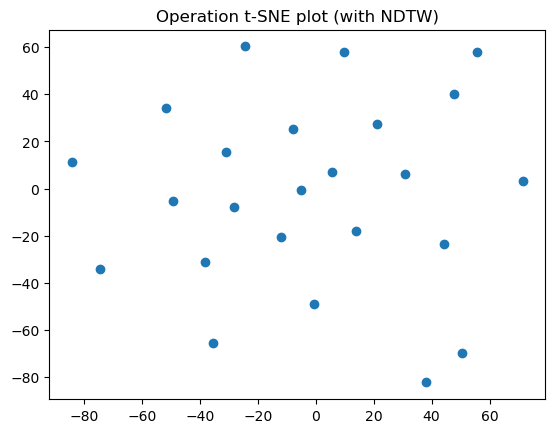

In [9]:
nDistMatrix = n_dtw(operations)
embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(nDistMatrix)


# plot
plt.title('Operation t-SNE plot (with NDTW)')
plt.scatter(embedding[:, 0], embedding[:, 1])
plt.show()

still doesnt make much of a difference

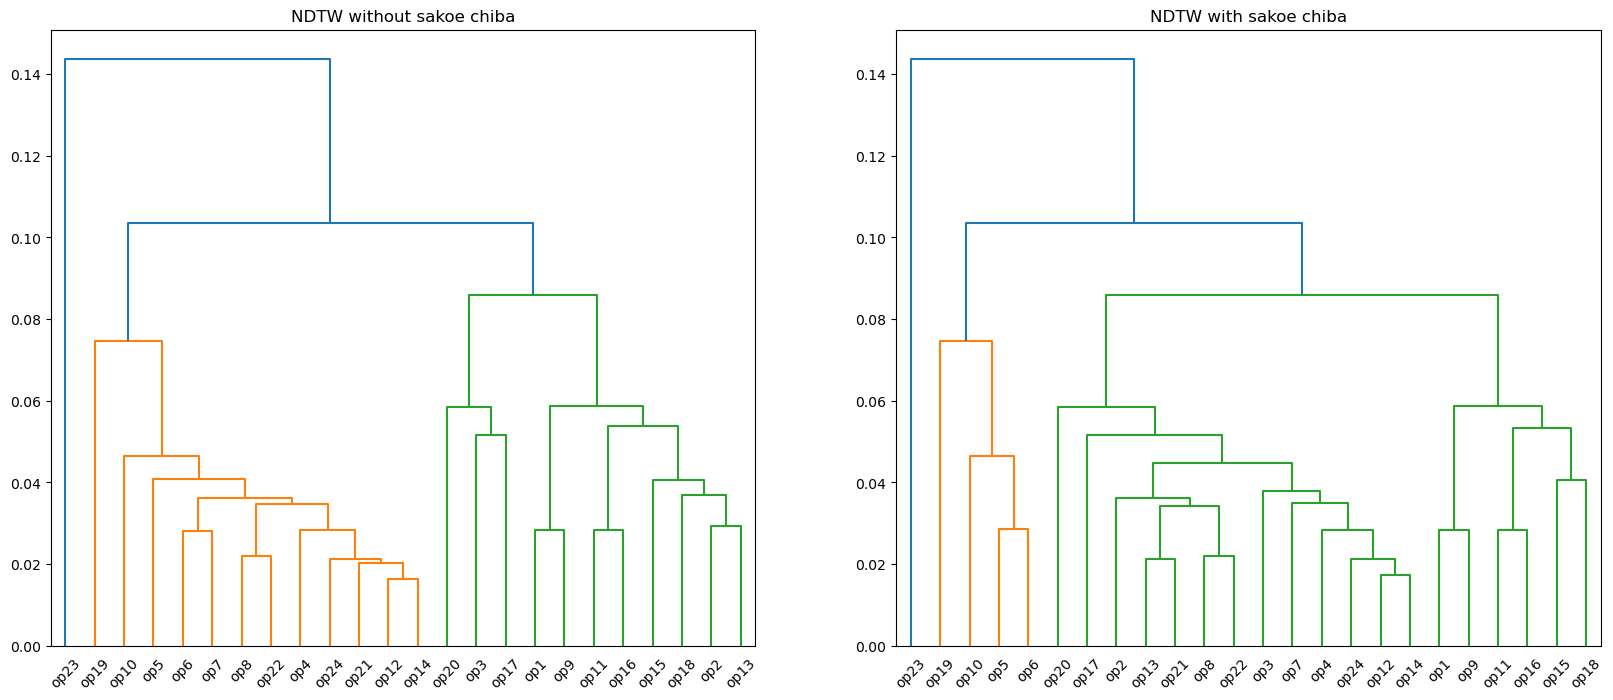

In [10]:
##hierachical clustering with and without sakoe chiba band
condensedDist = squareform(nDistMatrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix


nDistMatrix2 = n_dtw(operations, window = 5)
condensedDist2 = squareform(nDistMatrix2) #flattening squared distMatrix for hiearchical clustering
x_Chiba = linkage(condensedDist2, method='complete') #linkage matrix

##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x,  ax = ax1, labels = opLabels)
dendrogram(x_Chiba, ax = ax2, labels = opLabels)

ax1.set_title("NDTW without sakoe chiba")
ax2.set_title("NDTW with sakoe chiba")

plt.show()

Observations 
- 2 main clusters 
- After using ndtw, clusters seem to be more evenly distributed.
- Clusters are no longer operation length driven
    - ex: op8 and 22 are similar when operation 22 has way more frames
- operation 23 is an outlier alone in its own cluster which may be due to it having only 5 frames and having 3 clinicians consistently throughout it 

- Sakoe chiba band seems to be providing less evenly distributed clusters
- Would require labels for any further interpretation
    - Will cluster with other methods then obtain labels if cluster results overlap

In [11]:
#converting into flat labels
from scipy.cluster.hierarchy import fcluster

hierachical_labels = fcluster(x, t=3, criterion='maxclust') 

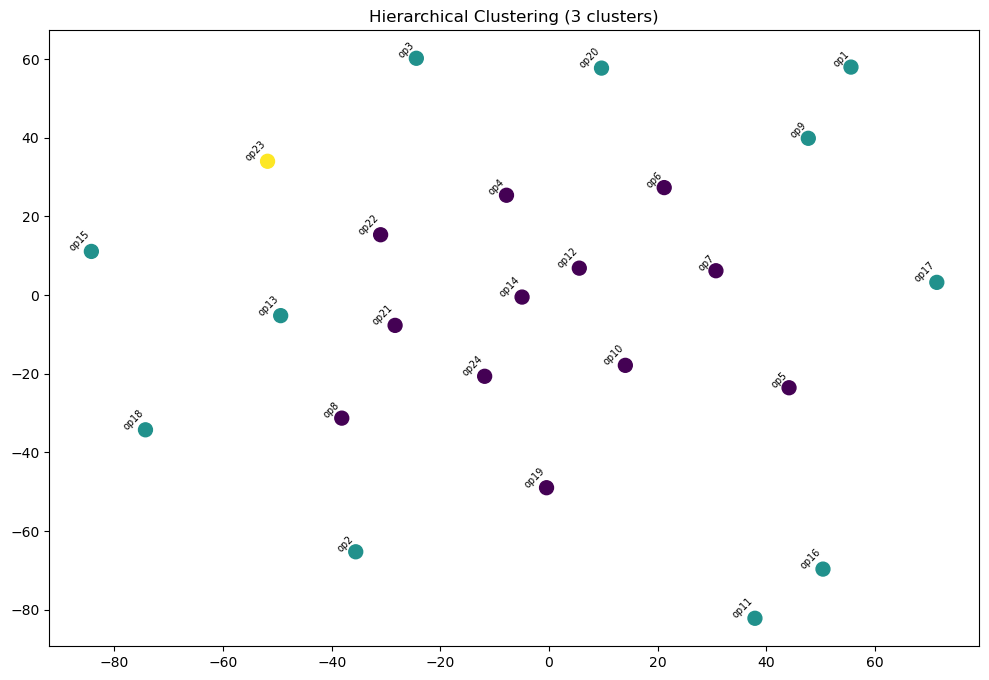

In [12]:
#visualizing
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=hierachical_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering (3 clusters)')
plt.show()

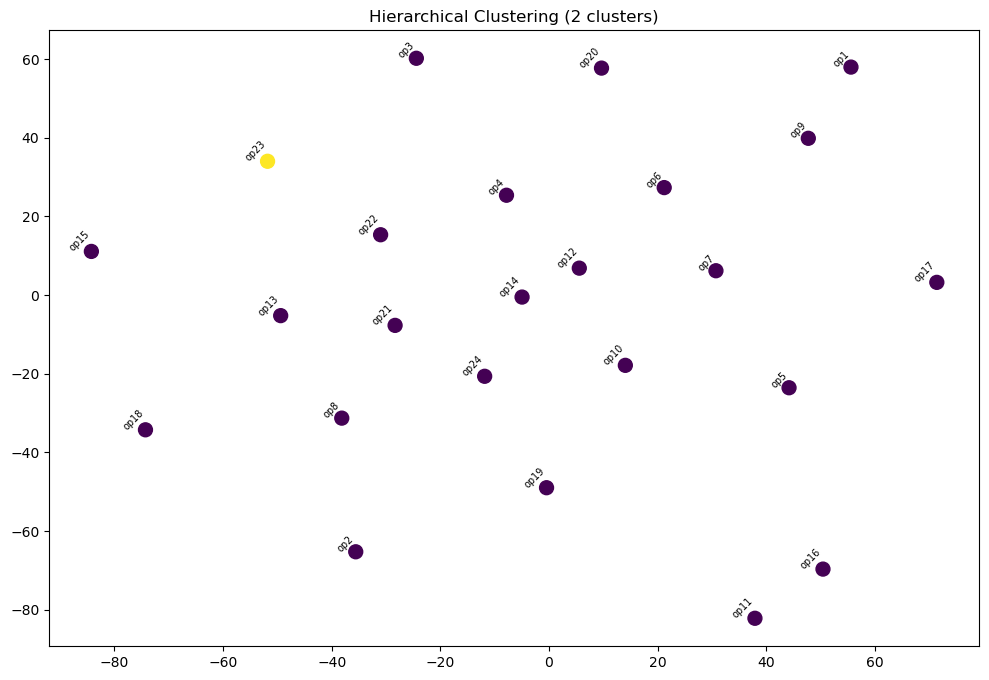

In [13]:
#visualizing
hierachical_labels2 = fcluster(x, t=2, criterion='maxclust') 
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=hierachical_labels2, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering (2 clusters)')
plt.show()

operation 23 is such an outlier that when nclusters = 2, it gets mapped to its own cluster

## K means with DBA

Since Kmeans is affected by initialization, we run k means multiples times and take best result (clustering with lowest inertia)

In [14]:
from dtaidistance.clustering.kmeans import KMeans

In [15]:
def multiple_KMeans(k=2, nRuns=10):
    results = {'inertia': 0.0}
    bestInertia = np.inf


    #distance: list of (cluster, distance from centroid) for each instance
    #clusteringEnded: boolean indicating whether the clustering has been stopped or not
    def computeInertia(distances, clusteringEnded):

        if clusteringEnded: #only compute when done
            results['inertia'] = sum(dist**2 for _, dist in distances)  

        return True #let it finish

    #finding best model
    for run in range(nRuns):
        model = KMeans(k=k, max_it = 100, max_dba_it = 100)
        cluster_idx = model.fit(operations, monitor_distances = computeInertia)

        #updating inertia 
        if results['inertia'] < bestInertia:
            bestInertia = results['inertia']
            bestCluster = cluster_idx
    
    #converting dict to flat array (should be [1,1,1,0,0....])
    cluster = np.zeros(len(operations))
    for cluster_id, op_indices in bestCluster[0].items():
        for idx in op_indices:
            cluster[idx] = cluster_id

    return bestInertia, cluster

In [16]:
inertia, cluster = multiple_KMeans()

  3%|▎         | 3/100 [00:06<03:27,  2.14s/it]


In [17]:
# #converting dict to flat array (should be [1,1,1,0,0....])
# cluster = np.zeros(len(operations))
# for cluster_id, op_indices in cluster_idx[0].items():
#     for idx in op_indices:
#         cluster[idx] = cluster_id

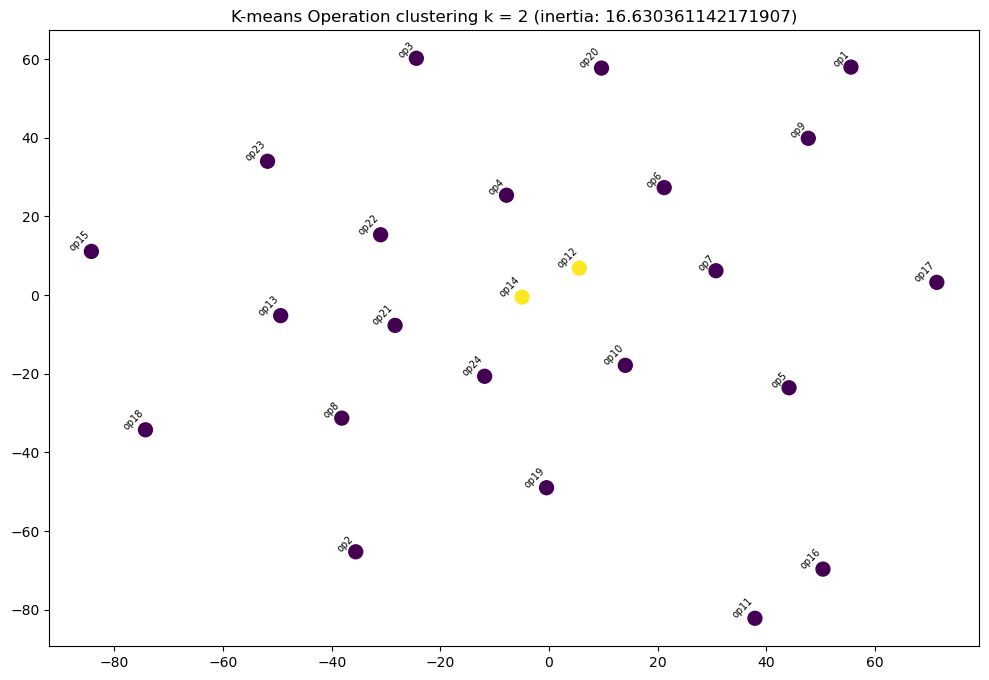

In [18]:
#plotting cluster assigments
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'K-means Operation clustering k = 2 (inertia: {inertia})')
plt.show()

Observations:
- Very uneven clustering
- Seems to be clustering based on operation length once more 
- 2 Longest operations in one cluster, rest in other cluster


  1%|          | 1/100 [00:02<04:19,  2.62s/it]


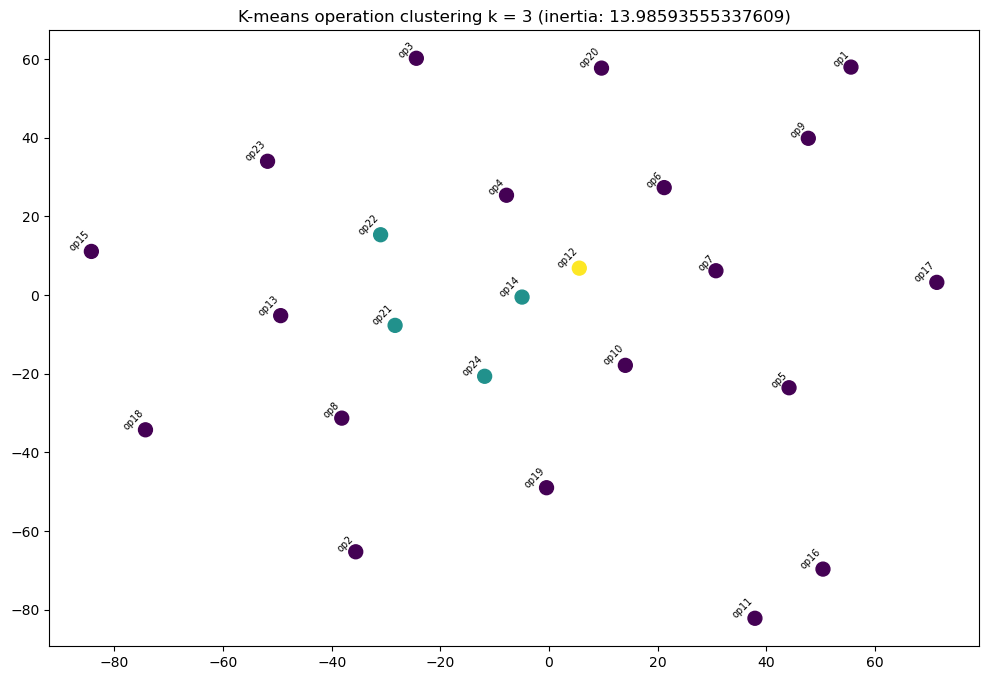

In [19]:
#trying different values of k

#k=3 following results of hiearchical clustering
inertia_k3, cluster_k3 = multiple_KMeans(k=3)
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'K-means operation clustering k = 3 (inertia: {inertia_k3})')
plt.show()

Observations
- Cluster assigment is driven by operation length
    - Longest frame in its own cluster
    - Next 5 longest in second cluster
    - Rest in their own cluster

  4%|▍         | 4/100 [00:08<03:27,  2.16s/it]


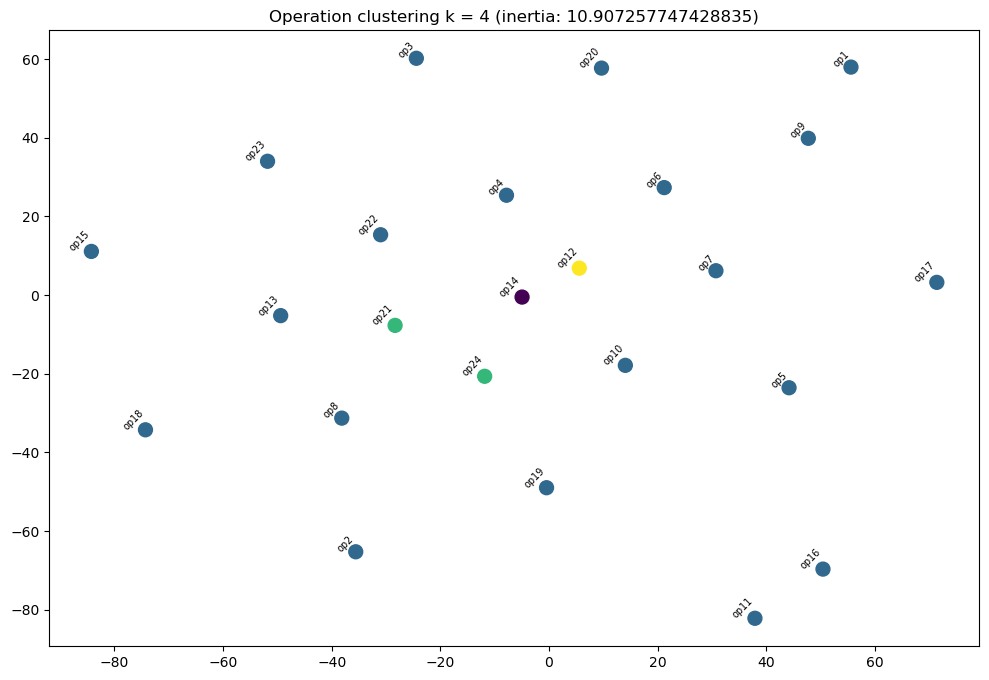

In [20]:

#k = 4, see if they cluster based on the days
inertia_k4, cluster_k4 = multiple_KMeans(k=4)
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster_k4, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 4 (inertia: {inertia_k4})')
plt.show()

Observations: 
- produced lower inertia than k=2 but algorithm still seemed to be catching operation length rather than actual pattenrns
    - 1st and 2nd longest ops in their own cluster 
    - 2 next longest in 3rd cluster
    - rest in 4th cluster


Results from Kmeans point towards using a version of algorithm more robust to length differences


## KMedioids 

In [21]:
from sklearn_extra.cluster import KMedoids
def multiple_KMedioids(k=2, nRuns=10):
    bestInertia = np.inf
    bestCluster = None 

    #finding best model
    for run in range(nRuns):
        kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=run)
        cluster_kmed = kmed.fit_predict(nDistMatrix) 

        #updating inertia 
        if kmed.inertia_ < bestInertia:
            bestInertia = kmed.inertia_
            bestCluster = cluster_kmed
    
    return bestInertia, bestCluster 

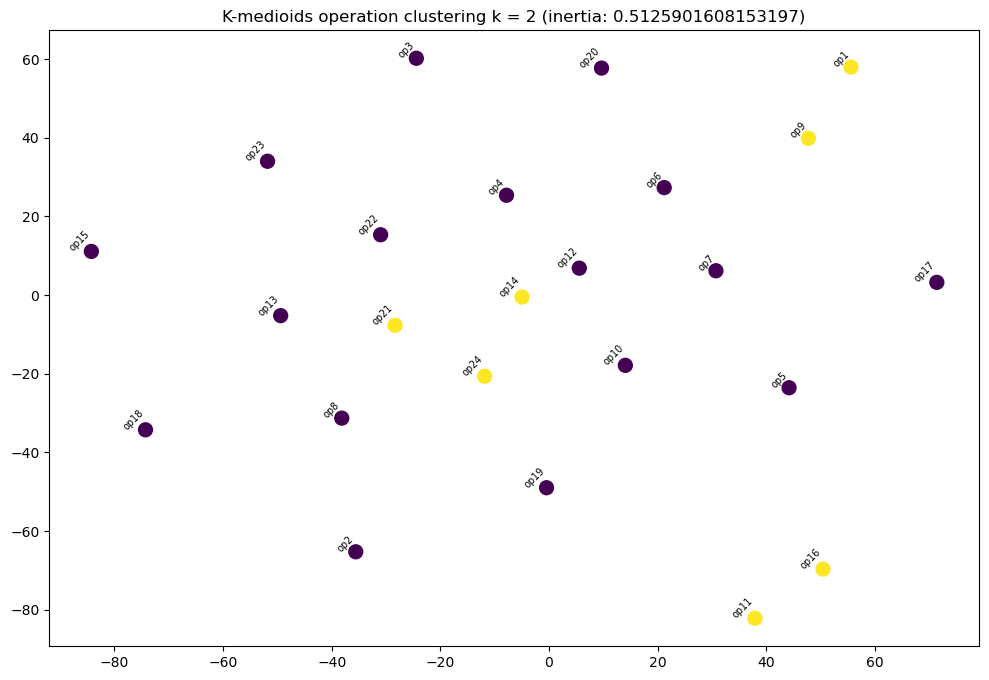

In [22]:
inertia, kmed_labels_k2 = multiple_KMedioids()

plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=kmed_labels_k2, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'K-medioids operation clustering k = 2 (inertia: {inertia})')
plt.show()

- operations are no longer length driven
- cluster is fragmented

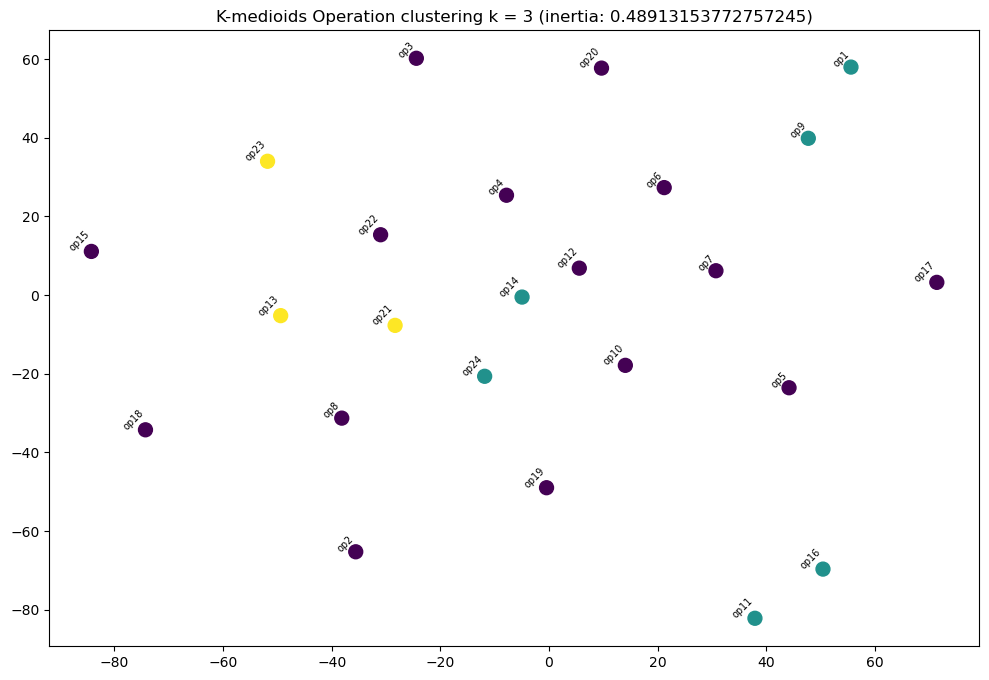

In [23]:
inertia_k3, kmed_labels_k3 = multiple_KMedioids(k=3) #k=3 following dendogram 

plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=kmed_labels_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'K-medioids Operation clustering k = 3 (inertia: {inertia_k3})')
plt.show()

clusters are still fragmented

## Spectral clustering

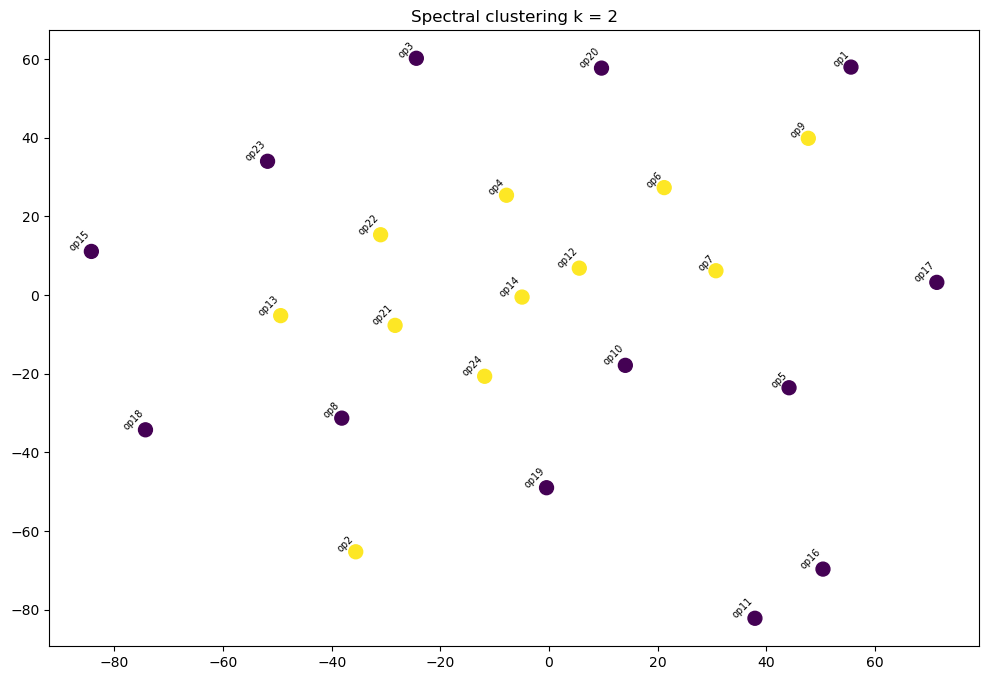

In [24]:
from sklearn.cluster import SpectralClustering


clustering = SpectralClustering(n_clusters=2, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(nDistMatrix)
spec_clustering_labels = clustering.labels_ 


plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=spec_clustering_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Spectral clustering k = 2')
plt.show()

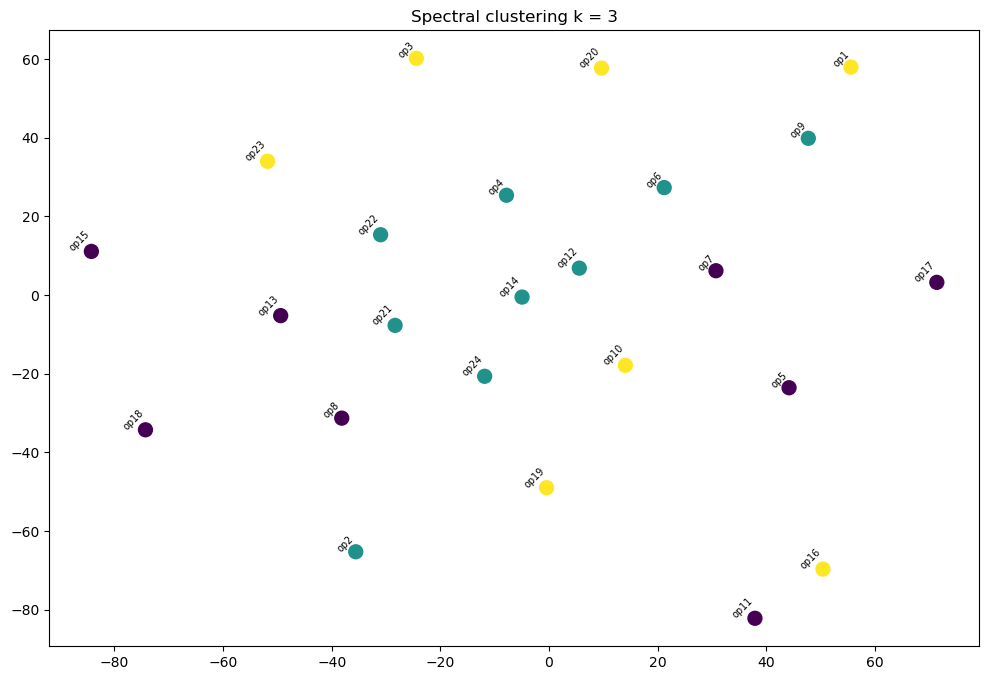

In [25]:
clusteringk3 = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(nDistMatrix)
spec_clustering_labels_k3 = clusteringk3.labels_ 


plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=spec_clustering_labels_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Spectral clustering k = 3')
plt.show()

## Evaluating cluster quality
Silhouette score for all 3 algorithms

In [26]:
from sklearn.metrics import silhouette_score


#measured with k=3 to match hiearchical clustering results
cluster_labels = [hierachical_labels, kmed_labels_k3, spec_clustering_labels_k3]

clustering_algorithms = ["Hiearchical clustering", "K-Medioids", "Spectral Clustering"]

for i, label in enumerate(cluster_labels):
    print(f'{clustering_algorithms[i]} silhouette score: {silhouette_score(nDistMatrix, label, metric = 'precomputed')}')

Hiearchical clustering silhouette score: 0.030846510491174886
K-Medioids silhouette score: 0.03637902948641699
Spectral Clustering silhouette score: -0.23246837298571843


In [27]:
print(silhouette_score(nDistMatrix, spec_clustering_labels, metric = 'precomputed'))
print(silhouette_score(nDistMatrix, kmed_labels_k2, metric = 'precomputed'))


-0.15435532341416655
0.000971018991458017


Silhouette scores are near zero indicating poor cluster seperation

## Evaluating cluster agreement 
Using ARI and Fowlkes Mallows Index

In [28]:
from sklearn.metrics.cluster import adjusted_rand_score, fowlkes_mallows_score

for i, label in enumerate(cluster_labels):
    for j in range(i+1, len(cluster_labels)):
        print(f'{clustering_algorithms[i]}, {clustering_algorithms[j]} agreement')
        print("------------------------------------------")
        print("Labels:")
        print(f"    {clustering_algorithms[i]}: {label}")
        print(f"    {clustering_algorithms[j]}: {cluster_labels[j]}")

        print("Metrics:")
        print(f'    ARI: {adjusted_rand_score(label, cluster_labels[j])}')
        print(f'    FMI: {fowlkes_mallows_score(label, cluster_labels[j])}\n')



Hiearchical clustering, K-Medioids agreement
------------------------------------------
Labels:
    Hiearchical clustering: [2 2 2 1 1 1 1 1 2 1 2 1 2 1 2 2 2 2 1 2 1 1 3 1]
    K-Medioids: [1 0 0 0 0 0 0 0 1 0 1 0 2 1 0 1 0 0 0 0 2 0 2 1]
Metrics:
    ARI: 0.059875459045186014
    FMI: 0.47542580737010065

Hiearchical clustering, Spectral Clustering agreement
------------------------------------------
Labels:
    Hiearchical clustering: [2 2 2 1 1 1 1 1 2 1 2 1 2 1 2 2 2 2 1 2 1 1 3 1]
    Spectral Clustering: [2 1 2 1 0 1 0 0 1 2 0 1 0 1 0 2 0 0 2 2 1 1 2 1]
Metrics:
    ARI: 0.07203880284407209
    FMI: 0.41413996492652544

K-Medioids, Spectral Clustering agreement
------------------------------------------
Labels:
    K-Medioids: [1 0 0 0 0 0 0 0 1 0 1 0 2 1 0 1 0 0 0 0 2 0 2 1]
    Spectral Clustering: [2 1 2 1 0 1 0 0 1 2 0 1 0 1 0 2 0 0 2 2 1 1 2 1]
Metrics:
    ARI: -0.04356403090580306
    FMI: 0.34229931163677635



Cluster aggreements are either worse or near random chance 

In [29]:
print(f'ARI: {adjusted_rand_score(kmed_labels_k2, spec_clustering_labels)}')
print(f'FMI: {fowlkes_mallows_score(kmed_labels_k2, spec_clustering_labels)}')

ARI: -0.009457129421599875
FMI: 0.5190218205512398


Using k=2 on k-medioids and spectral clustering doesnt improve results

In [30]:
print(adjusted_rand_score(spec_clustering_labels, hierachical_labels))

0.09742075003955905


## Plotting t-SNE with polar coordinates

Since clusters seem to be concentric we try to see if this provides different results. Viewing from center focal point while keeping same shape. Treat embedding like x,y coordinate and convert to polar

In [31]:
np.shape(embedding)

(24, 2)

In [32]:
print(embedding)

[[ 55.594524    57.991913  ]
 [-35.57872    -65.29363   ]
 [-24.420713    60.233635  ]
 [ -7.824769    25.396646  ]
 [ 44.193203   -23.5694    ]
 [ 21.209908    27.339907  ]
 [ 30.73502      6.193322  ]
 [-38.150513   -31.297102  ]
 [ 47.7411      39.88003   ]
 [ 14.05689    -17.869715  ]
 [ 37.91566    -82.20538   ]
 [  5.5793204    6.851483  ]
 [-49.397064    -5.2264843 ]
 [ -4.9586234   -0.5046061 ]
 [-84.25008     11.106119  ]
 [ 50.442474   -69.69747   ]
 [ 71.40121      3.2357404 ]
 [-74.28966    -34.266407  ]
 [ -0.45150098 -48.997307  ]
 [  9.668426    57.734596  ]
 [-28.33294     -7.704754  ]
 [-30.998442    15.347368  ]
 [-51.81374     34.036156  ]
 [-11.843525   -20.653204  ]]


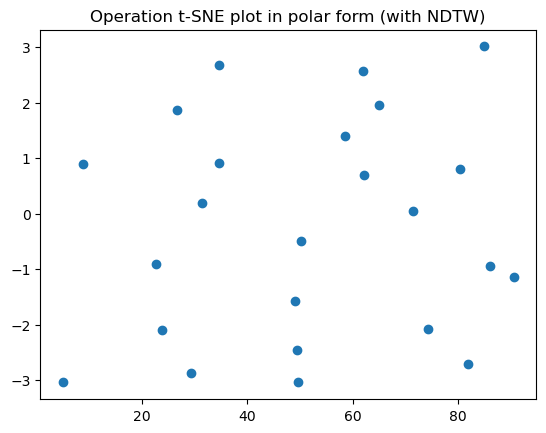

In [33]:
#convert to polar formulas
theta = np.arctan2(embedding[:, 1],embedding[:, 0])
r = np.sqrt(embedding[:, 0]**2 + embedding[:, 1]**2)

plt.title('Operation t-SNE plot in polar form (with NDTW)')
plt.scatter(r, theta)
plt.show()

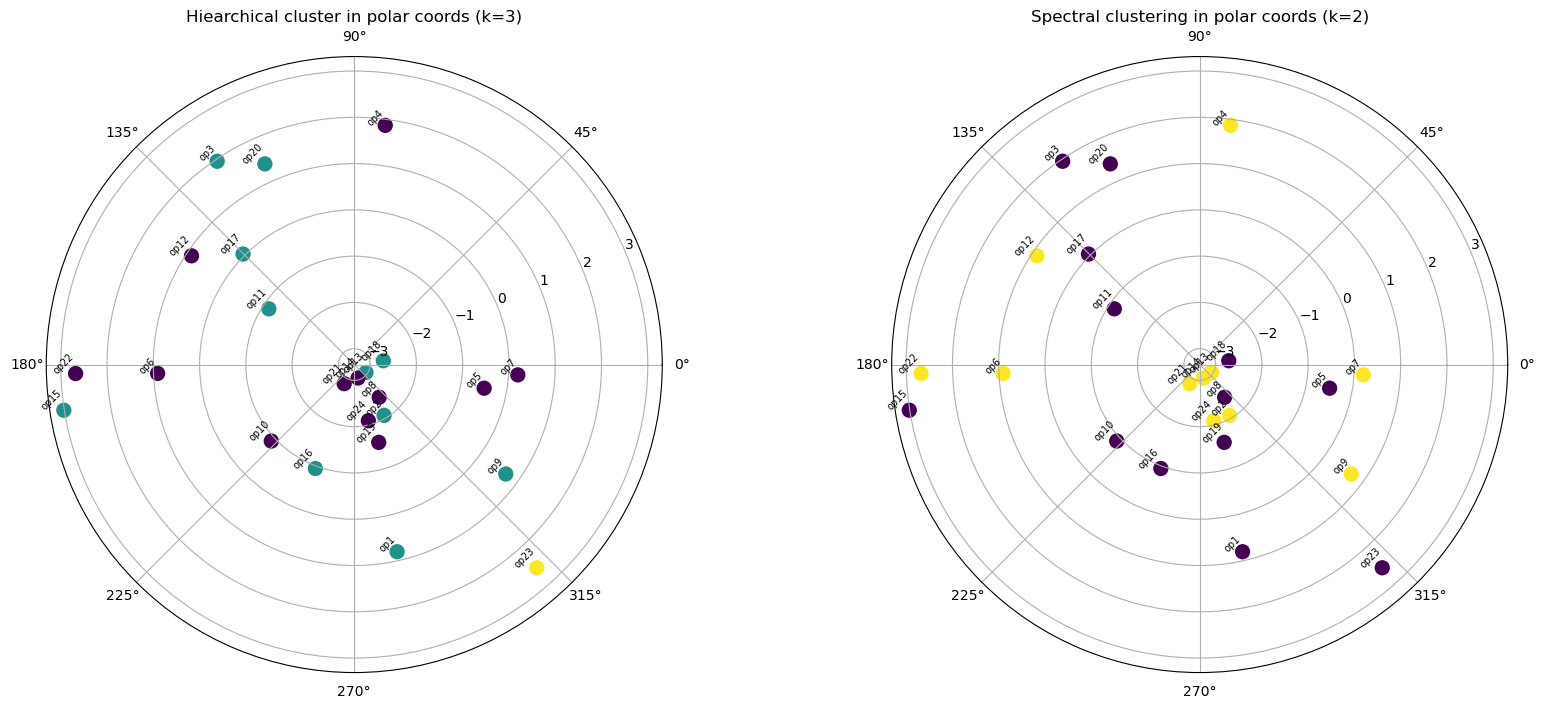

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, subplot_kw={'projection': 'polar'}, figsize=(20, 8))

ax1.scatter(r,theta, c=hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (r[i], theta[i]), fontsize=7, ha='right', rotation=45)

ax1.set_title("Hiearchical cluster in polar coords (k=3)")

ax2.scatter(r,theta, c=spec_clustering_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (r[i], theta[i]), fontsize=7, ha='right', rotation=45)
    
ax2.set_title("Spectral clustering in polar coords (k=2)")

plt.show()

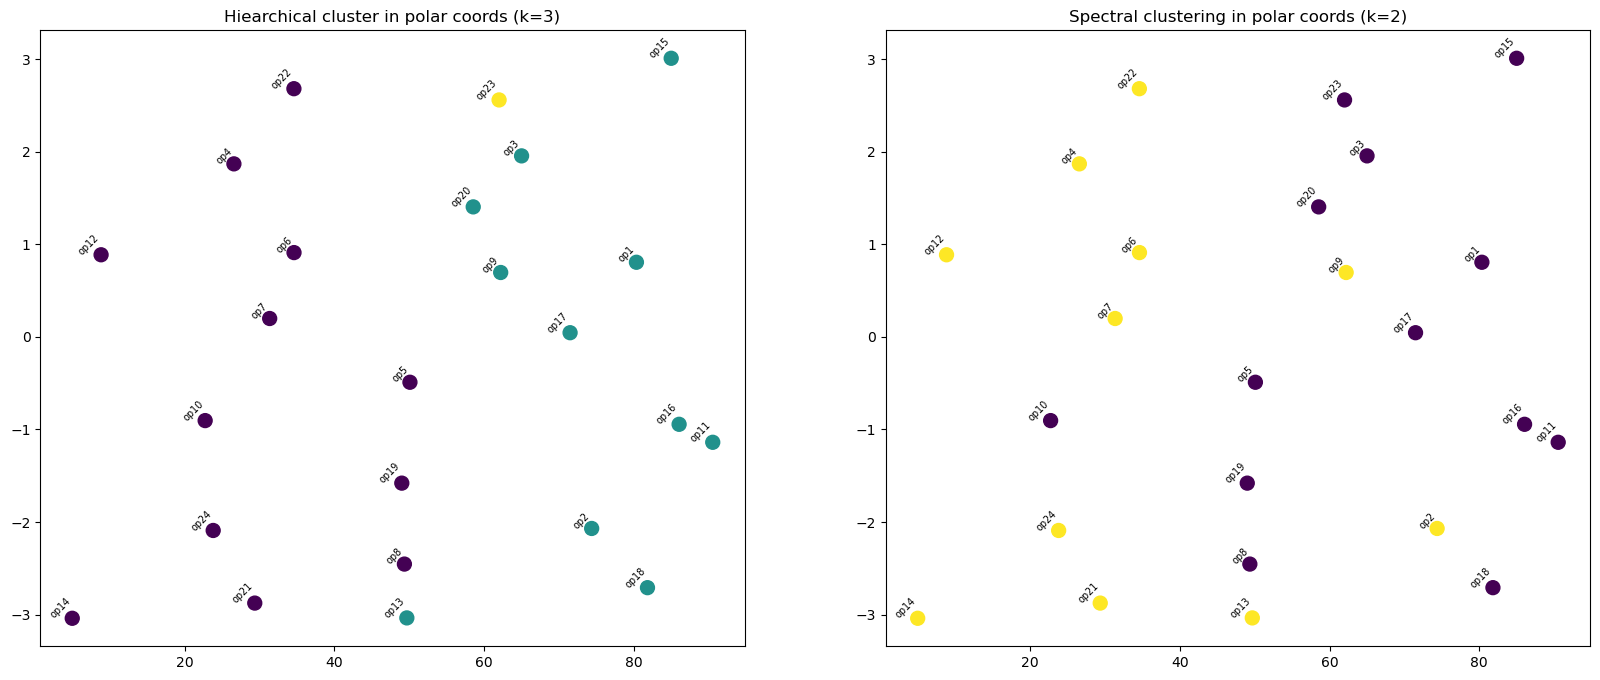

In [35]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(r,theta, c=hierachical_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (r[i], theta[i]), fontsize=7, ha='right', rotation=45)

ax1.set_title("Hiearchical cluster in polar coords (k=3)")

ax2.scatter(r,theta, c=spec_clustering_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (r[i], theta[i]), fontsize=7, ha='right', rotation=45)
    
ax2.set_title("Spectral clustering in polar coords (k=2)")

plt.show()

Results look as insignificant in polar form

## K-means w DBA (nDTW distance)

In [114]:
from DBA_multivariate import*

In [115]:
def assign_centroids(X, centroids, cost_mat, delta_mat, tmp_delta_mat):
    labels = [] 
    for x in X:
        dists = [] #distance to each centroid
        for centroid in centroids:
            dists.append(squared_DTW(x, centroid, cost_mat, delta_mat, tmp_delta_mat))
        
        labels.append(np.argmin(dists))

    labels = np.array(labels)
    return labels


def update_centroids(X, k, labels):
    new_centroids = []
    for i in range(k):
        series_in_cluster = []
        for x, l in zip(X, labels):
            if l == i:
                series_in_cluster.append(x)
        
        new_centroids.append(performDBA(series_in_cluster))

    return new_centroids

def compute_inertia(X, N, labels, centroids, cost_mat, delta_mat, tmp_delta_mat):
    inertia = 0
    for i in range(N):
        inertia += squared_DTW(X[i], centroids[labels[i]], cost_mat, delta_mat, tmp_delta_mat)

    return inertia

In [116]:
def kMeans_nDTW(X, k = 2, n_runs = 10, max_iter=100, random_state = None):
    '''
    X: operations
    k: # clusters
    n_runs: number of times we run algorithm before choosing best result
    max_iter: number of mean in kmeans algorithm
    random_state: param used to init random number generator


    return:
        - clustering labels
        - inertia
    '''

    rng = np.random.RandomState(random_state)
    N = len(X)
    bestInertia = np.inf
    bestLabels = None 

    #allocate matrices for NDTW computations
    max_length = max(x.shape[0] for x in X)
    cost_mat = np.zeros((max_length, max_length))
    delta_mat = np.zeros((max_length, max_length))
    tmp_delta_mat = np.zeros((max_length, max_length))
    path_mat = np.zeros((max_length, max_length), dtype=np.int8)



    for run in range(n_runs):

        #init centroids 
        centroid_indices = rng.choice(N, k, replace=False)
        centroids = [X[i] for i in centroid_indices]
        labels = np.zeros(N)

        for iteration in range(max_iter):
            prev_labels = labels.copy() 

            # assign each operation to nearest centroid (lowest nDTW dist)
            labels = assign_centroids(X, centroids, cost_mat, delta_mat, tmp_delta_mat)

            #update centroid
            centroids = update_centroids(X,k,labels)

            # check convergence
            if np.allclose(labels, prev_labels):
                break


        #compute inertia
        inertia = compute_inertia(X, N, labels, centroids, cost_mat, delta_mat, tmp_delta_mat)


        #updating best inertia 
        if inertia < bestInertia:
            bestInertia = inertia
            bestLabel = labels
    
    return bestInertia, bestLabel

In [40]:
nKmeans_inertia_k2, nKmeans_k2 = kMeans_nDTW(operations)
nKmeans_inertia_k3, nKmeans_k3 = kMeans_nDTW(operations, k = 3)


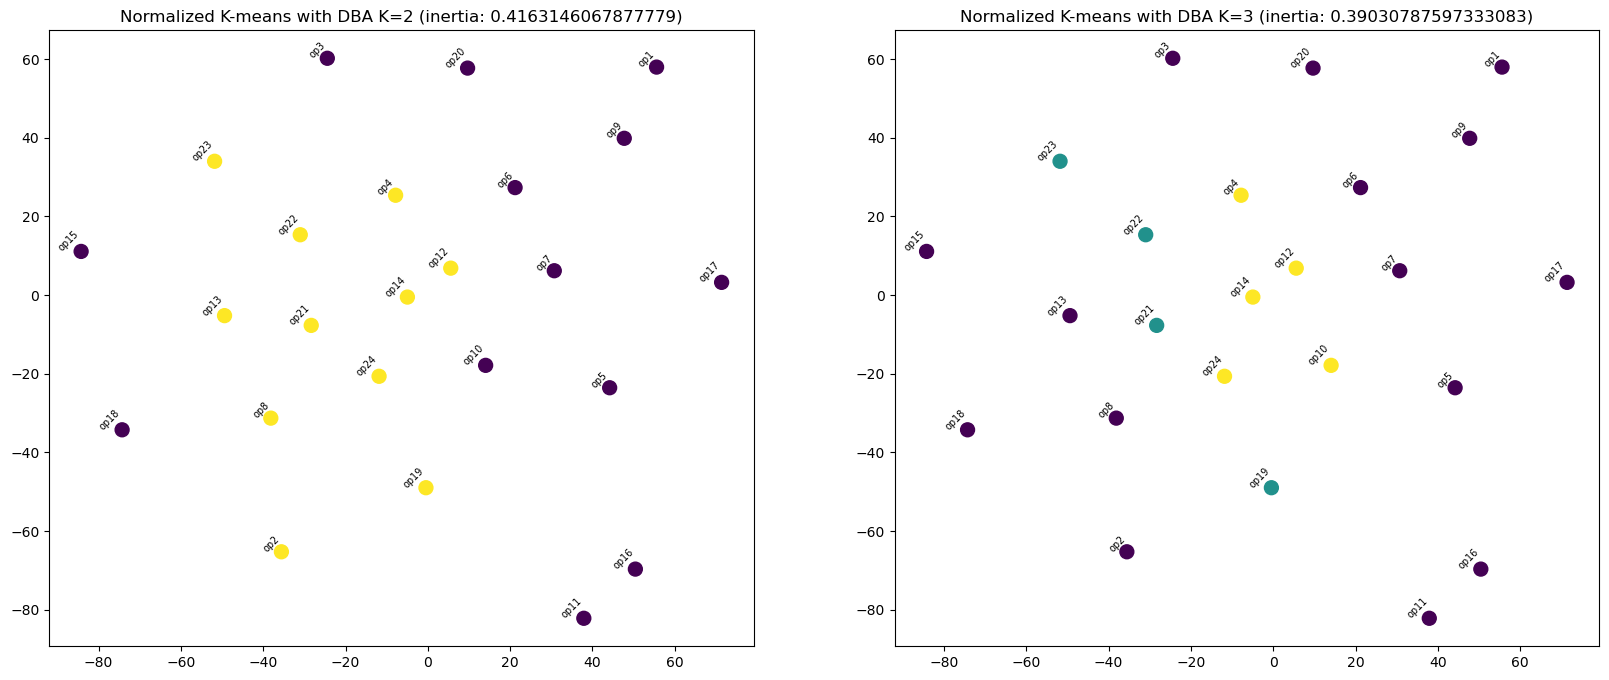

In [41]:
#plotting results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(embedding[:, 0],embedding[:,1], c=nKmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(embedding[:, 0],embedding[:,1], c=nKmeans_k3, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Normalized K-means with DBA K=2 (inertia: {nKmeans_inertia_k2})")
ax2.set_title(f"Normalized K-means with DBA K=3 (inertia: {nKmeans_inertia_k3})")

plt.show()

In [42]:
print(f"{adjusted_rand_score(nKmeans_k2,hierachical_labels)}")

0.1847671290679888


## Measuring cluster robustness

In [43]:
try:
    with open('first90percent.pkl', 'rb') as f:
        first90_ops = pickle.load(f)


    with open('last90percent.pkl', 'rb') as f:
        last90_ops = pickle.load(f)

    with open('operation_chunks', 'rb') as f:
        operation_chunks = pickle.load(f)
    
except:
    print("Error")




### Comparing clusters between first 90% frames and last 90% frames

In [44]:
first90_matrix = n_dtw(first90_ops)
first90_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(first90_matrix)

last90_matrix = n_dtw(last90_ops)
last90_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(last90_matrix)


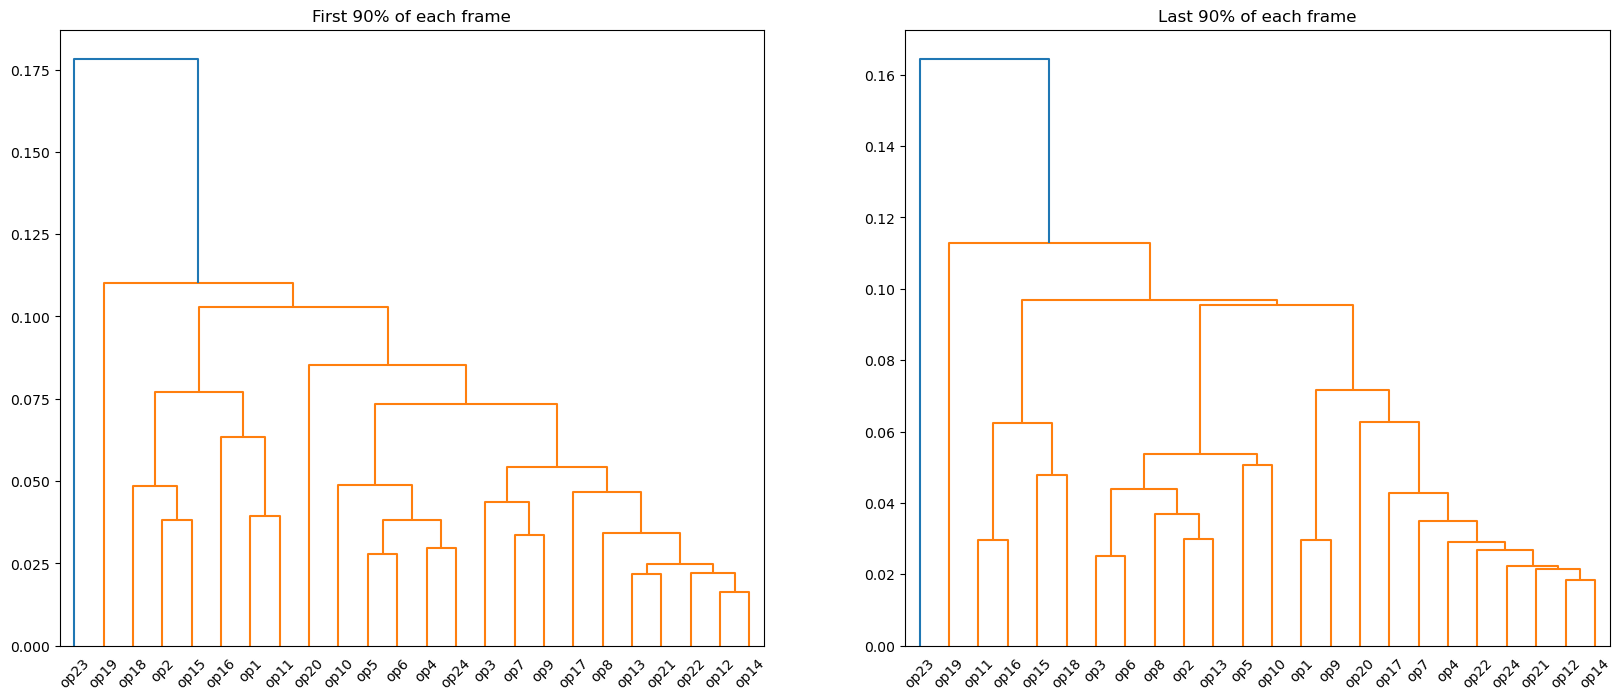

In [45]:
##hierachical clustering on first and last 90% frames of each operation
condensedDist = squareform(first90_matrix)
x_first = linkage(condensedDist, method='complete') #linkage matrix


condensedDist2 = squareform(last90_matrix) #flattening squared distMatrix for hiearchical clustering
x_last = linkage(condensedDist2, method='complete') #linkage matrix

##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x_first,  ax = ax1, labels = opLabels)
dendrogram(x_last, ax = ax2, labels = opLabels)

ax1.set_title(f"First 90% of each frame")
ax2.set_title(f"Last 90% of each frame")

plt.show()

ARI: 0.32667997338656024


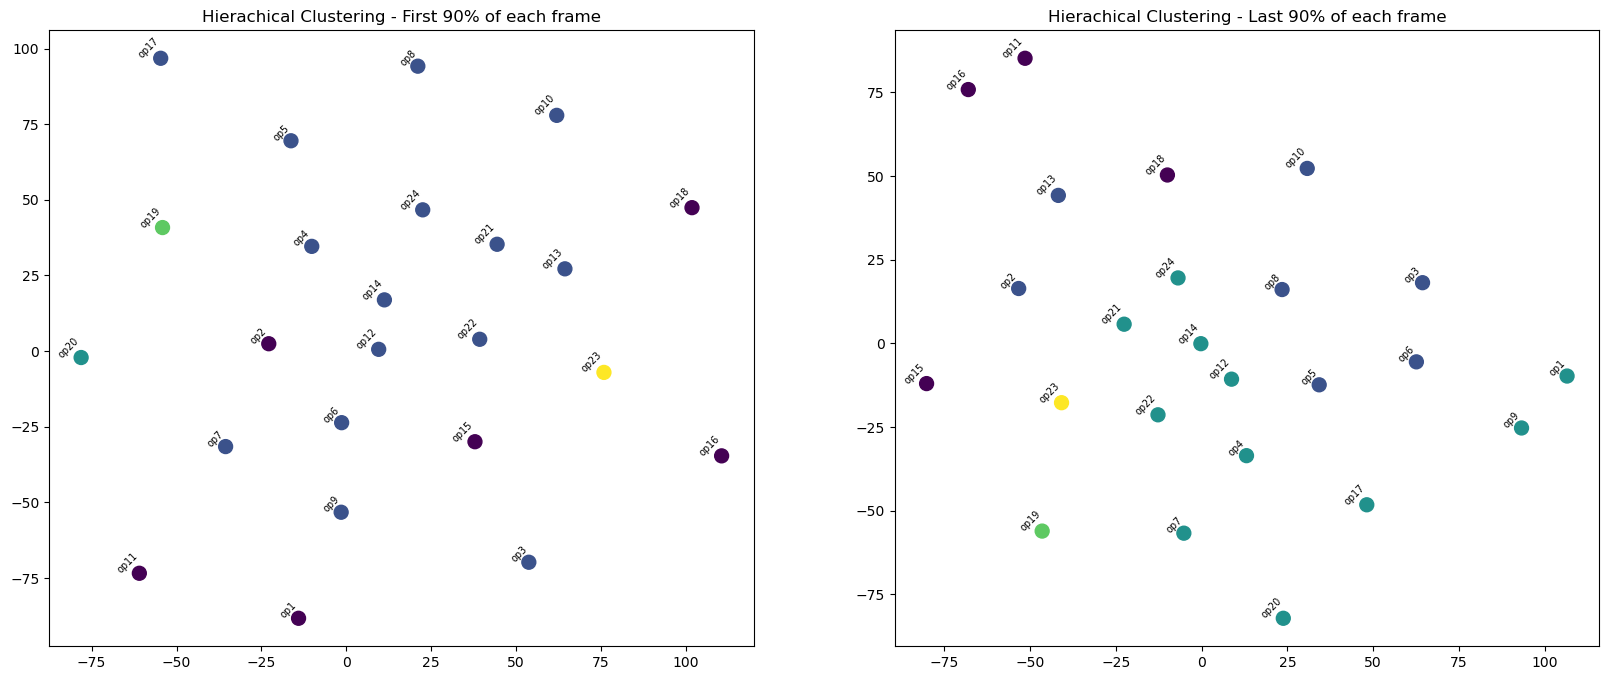

In [47]:
#plotting on t-SNE plot 
first90_hierachical = fcluster(x_first, t=5, criterion='maxclust') 
last90_hierachical = fcluster(x_last, t=5, criterion='maxclust') 

#checking aggreement
print(f'ARI: {adjusted_rand_score(first90_hierachical, last90_hierachical)}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_hierachical, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=last90_hierachical, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Hierachical Clustering - First 90% of each frame")
ax2.set_title(f"Hierachical Clustering - Last 90% of each frame")

plt.show()

ARI: 0.3960441059452086


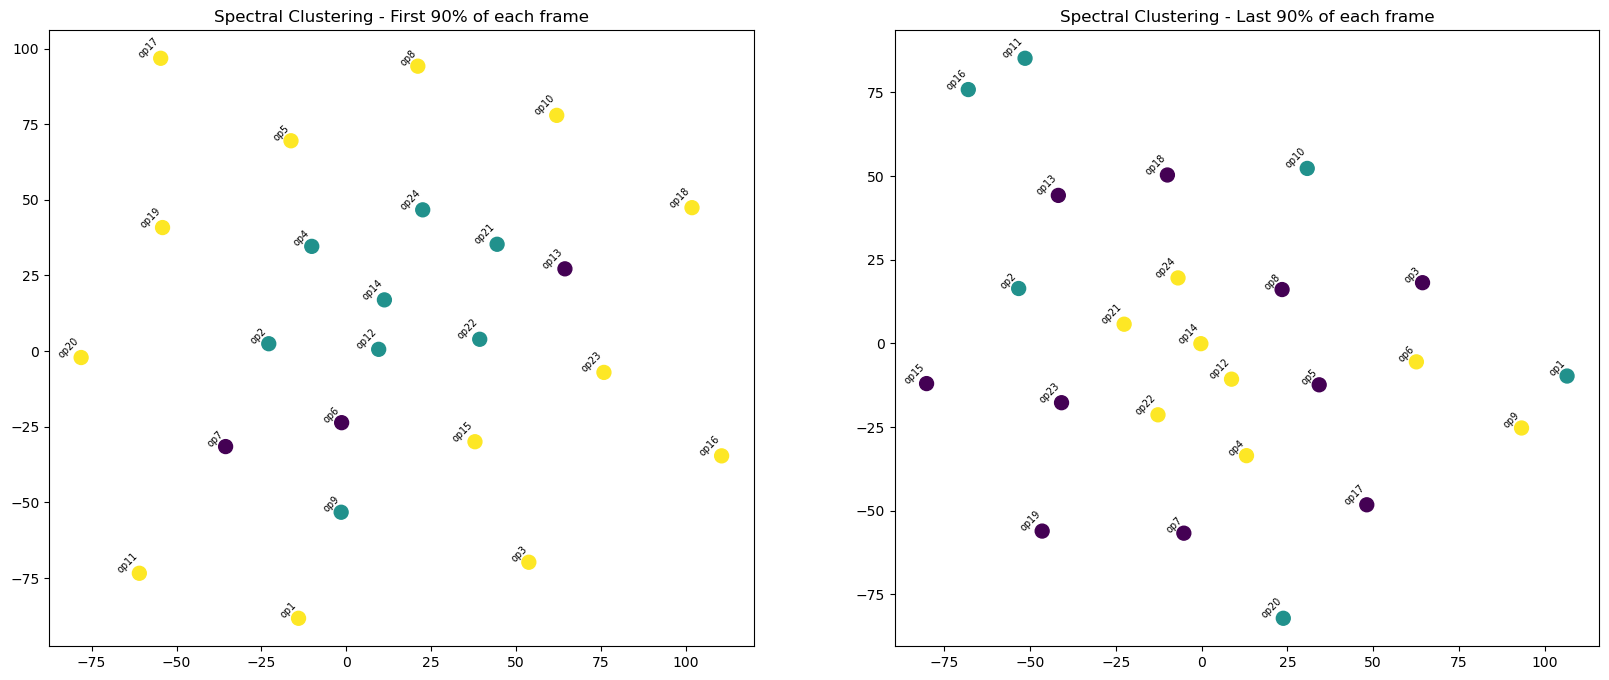

In [48]:
#spectral clustering
first90_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(first90_matrix).labels_
last90_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(last90_matrix).labels_


#checking aggreement
print(f'ARI: {adjusted_rand_score(first90_spectral, last90_spectral)}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_spectral, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=last90_spectral, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Spectral Clustering - First 90% of each frame")
ax2.set_title(f"Spectral Clustering - Last 90% of each frame")

plt.show()

In [50]:
## kmeans 
_, first90_kmeans_k2 = kMeans_nDTW(first90_ops)
_, last90_kmeans_k2= kMeans_nDTW(last90_ops)

_, first90_kmeans_k3 = kMeans_nDTW(first90_ops , k=3)
_, last90_kmeans_k3= kMeans_nDTW(last90_ops, k=3)

ARI K2 : 0.8332457707260691
ARI K3 : 0.2880417073965461


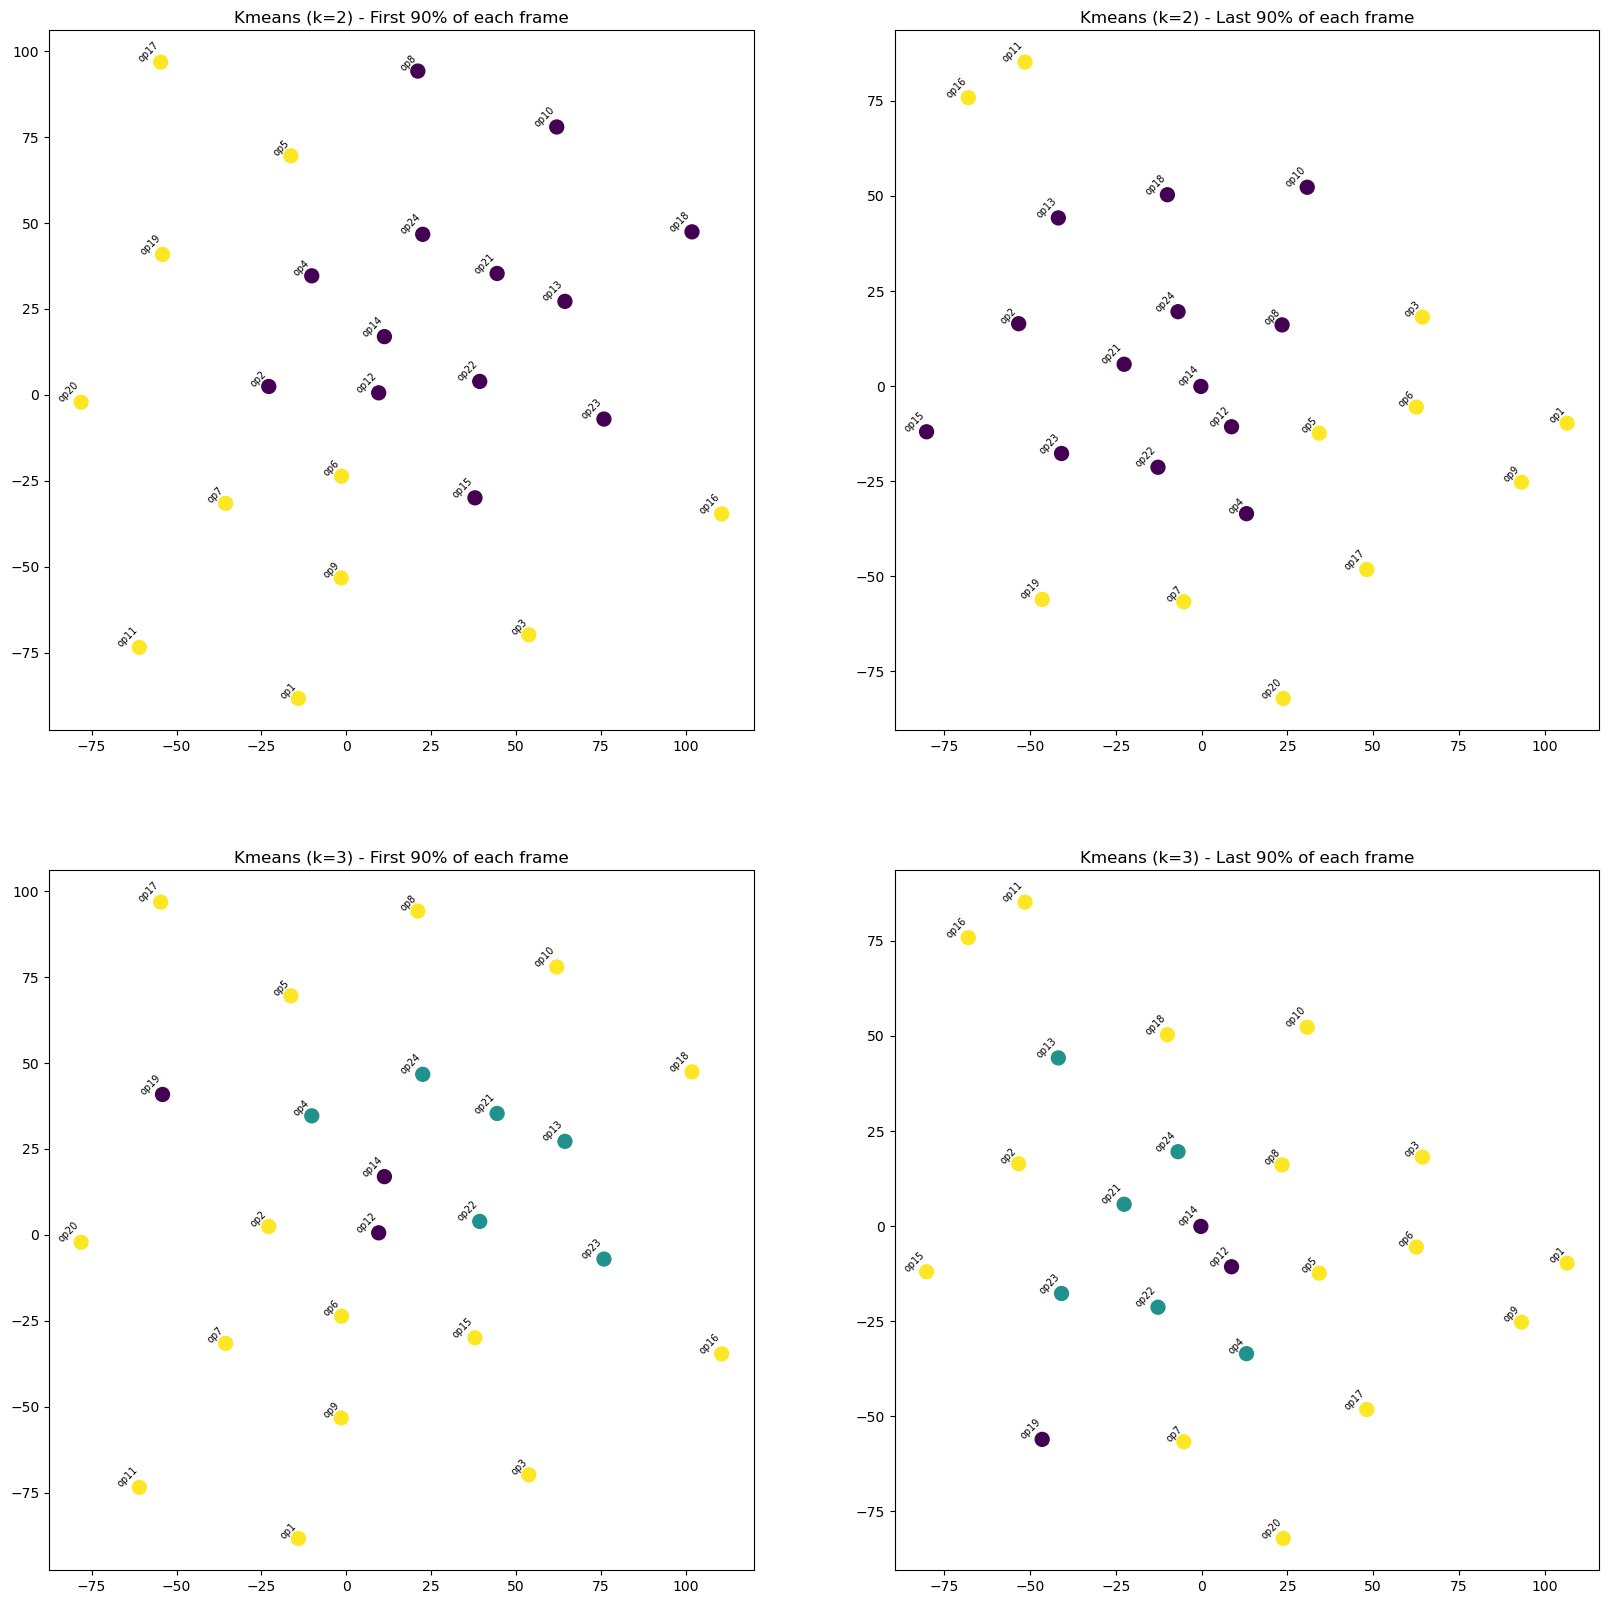

In [51]:
print(f'ARI K2 : {adjusted_rand_score(first90_kmeans_k2, last90_kmeans_k2)}')
print(f'ARI K3 : {adjusted_rand_score(first90_kmeans_k3, last90_kmeans_k3)}')


fig, axes = plt.subplots(2, 2, figsize=(20, 20))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=first90_kmeans_k2, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    
ax3.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_kmeans_k3, s=100)

for i, op in enumerate(opLabels):
    ax3.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax4.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=first90_kmeans_k3, s=100)

for i, op in enumerate(opLabels):
    ax4.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax1.set_title(f"Kmeans (k=2) - First 90% of each frame")
ax2.set_title(f"Kmeans (k=2) - Last 90% of each frame")
ax3.set_title(f"Kmeans (k=3) - First 90% of each frame")
ax4.set_title(f"Kmeans (k=3) - Last 90% of each frame")

plt.show()

#### Removing op23 (outlier) and seeing if results change

In [52]:
len(first90_ops)

24

In [53]:
del first90_ops[22]
del last90_ops[22]

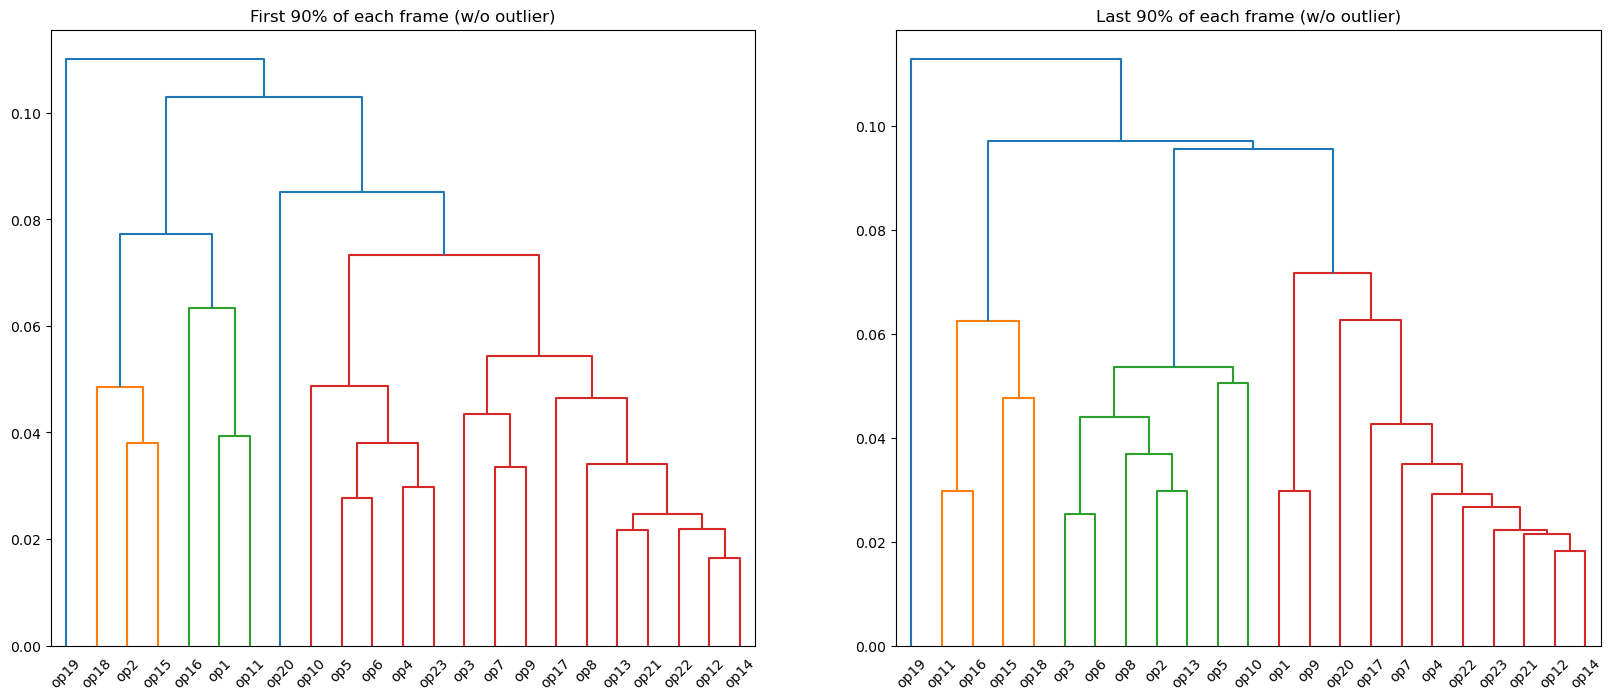

In [54]:
newOpLabels = [f"op{i}" for i in range(1,24)]

first90_matrix = n_dtw(first90_ops)
first90_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(first90_matrix)

last90_matrix = n_dtw(last90_ops)
last90_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(last90_matrix)

##hierachical clustering on first and last 90% frames of each operation
condensedDist = squareform(first90_matrix)
x_first = linkage(condensedDist, method='complete') #linkage matrix


condensedDist2 = squareform(last90_matrix) #flattening squared distMatrix for hiearchical clustering
x_last = linkage(condensedDist2, method='complete') #linkage matrix


##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x_first,  ax = ax1, labels = newOpLabels)
dendrogram(x_last, ax = ax2, labels = newOpLabels)

ax1.set_title(f"First 90% of each frame (w/o outlier)")
ax2.set_title(f"Last 90% of each frame (w/o outlier)")

plt.show()

ARI: 0.6782398575607275


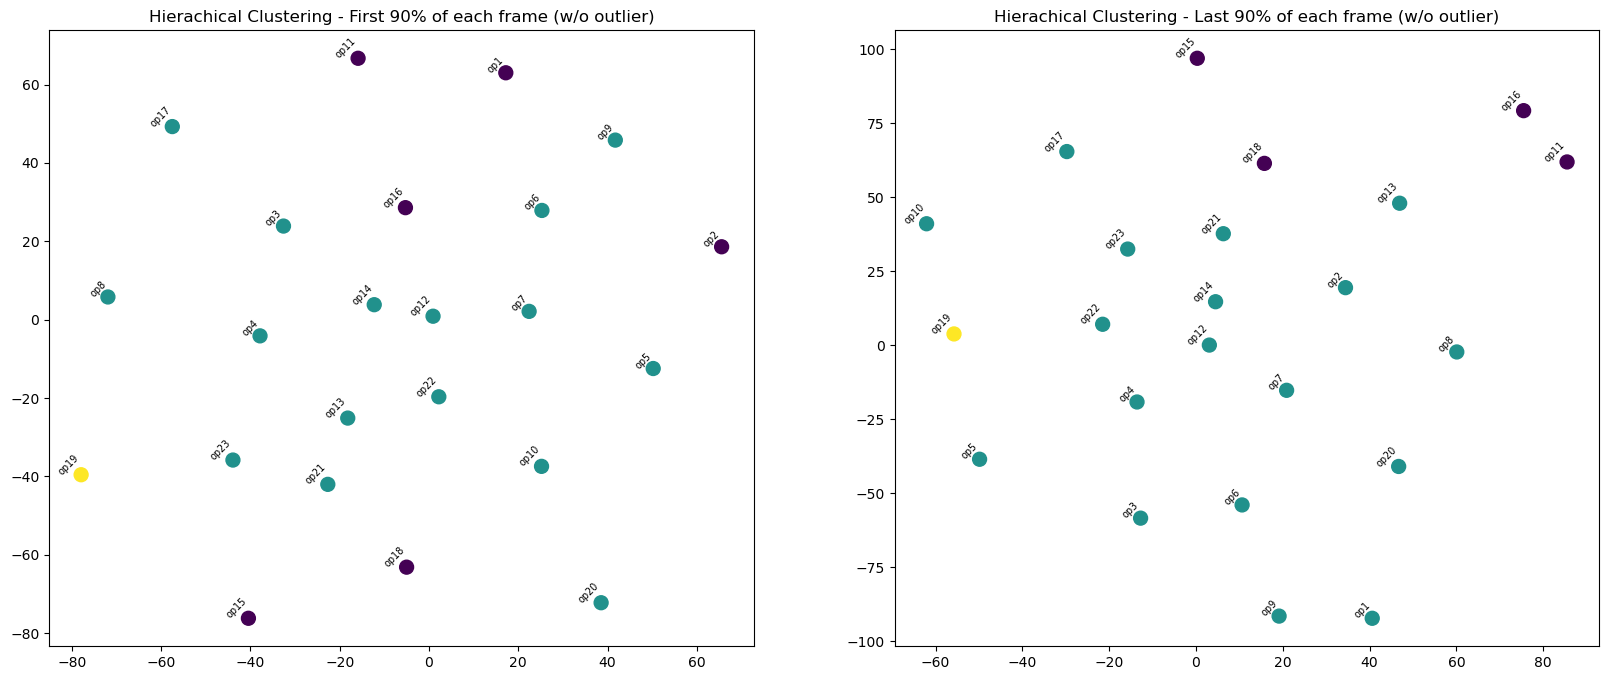

In [55]:
#plotting on t-SNE plot 
first90_hierachical = fcluster(x_first, t=3, criterion='maxclust') 
last90_hierachical = fcluster(x_last, t=3, criterion='maxclust') 

#checking aggreement
print(f'ARI: {adjusted_rand_score(first90_hierachical, last90_hierachical)}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_hierachical, s=100)

for i, op in enumerate(newOpLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=last90_hierachical, s=100)

for i, op in enumerate(newOpLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Hierachical Clustering - First 90% of each frame (w/o outlier)")
ax2.set_title(f"Hierachical Clustering - Last 90% of each frame (w/o outlier)")

plt.show()


ARI: 0.4553673938002296


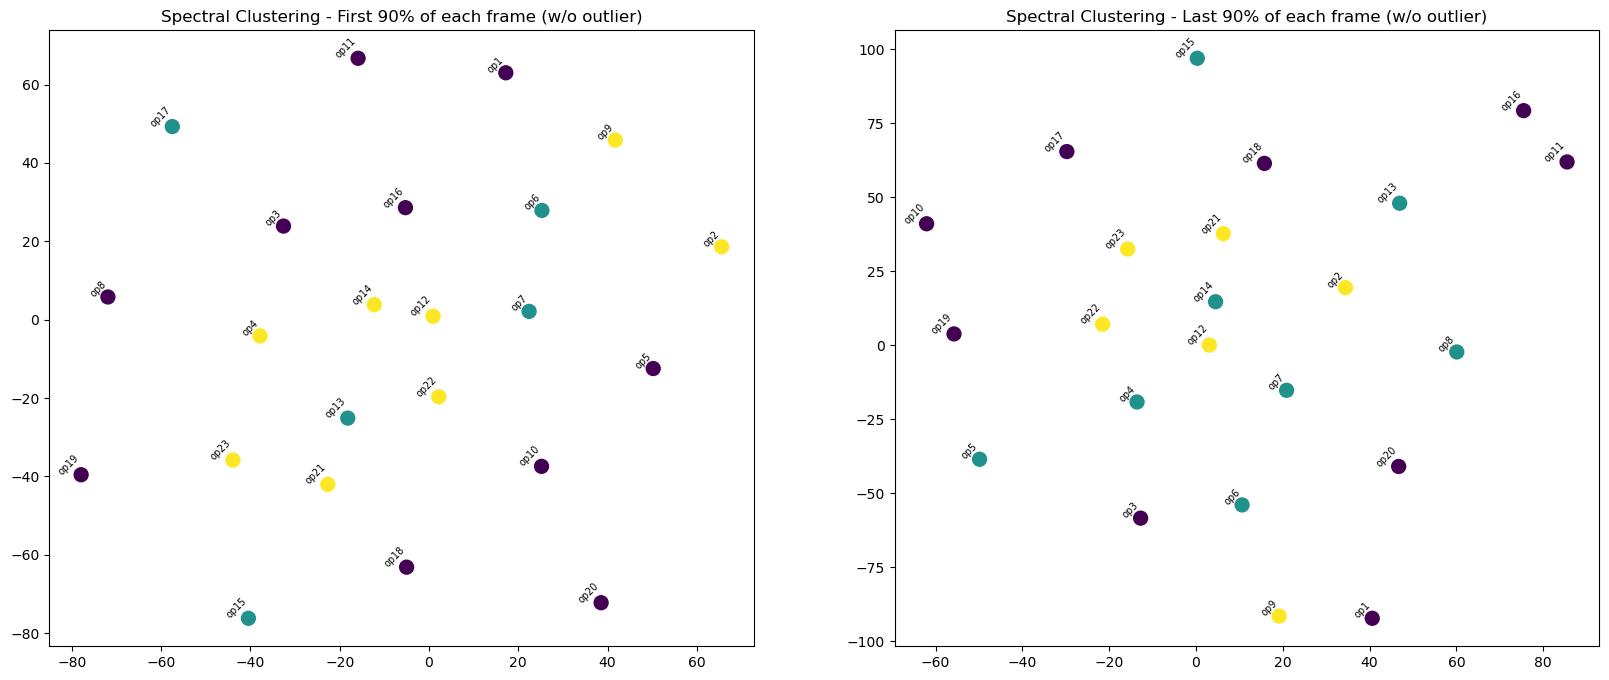

In [56]:
#spectral clustering
first90_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(first90_matrix).labels_
last90_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(last90_matrix).labels_


#checking aggreement
print(f'ARI: {adjusted_rand_score(first90_spectral, last90_spectral)}')


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_spectral, s=100)

for i, op in enumerate(newOpLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=last90_spectral, s=100)

for i, op in enumerate(newOpLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Spectral Clustering - First 90% of each frame (w/o outlier)")
ax2.set_title(f"Spectral Clustering - Last 90% of each frame (w/o outlier)")

plt.show()

ARI K2 : 0.2895475819032761
ARI K3 : 0.28254253700373494


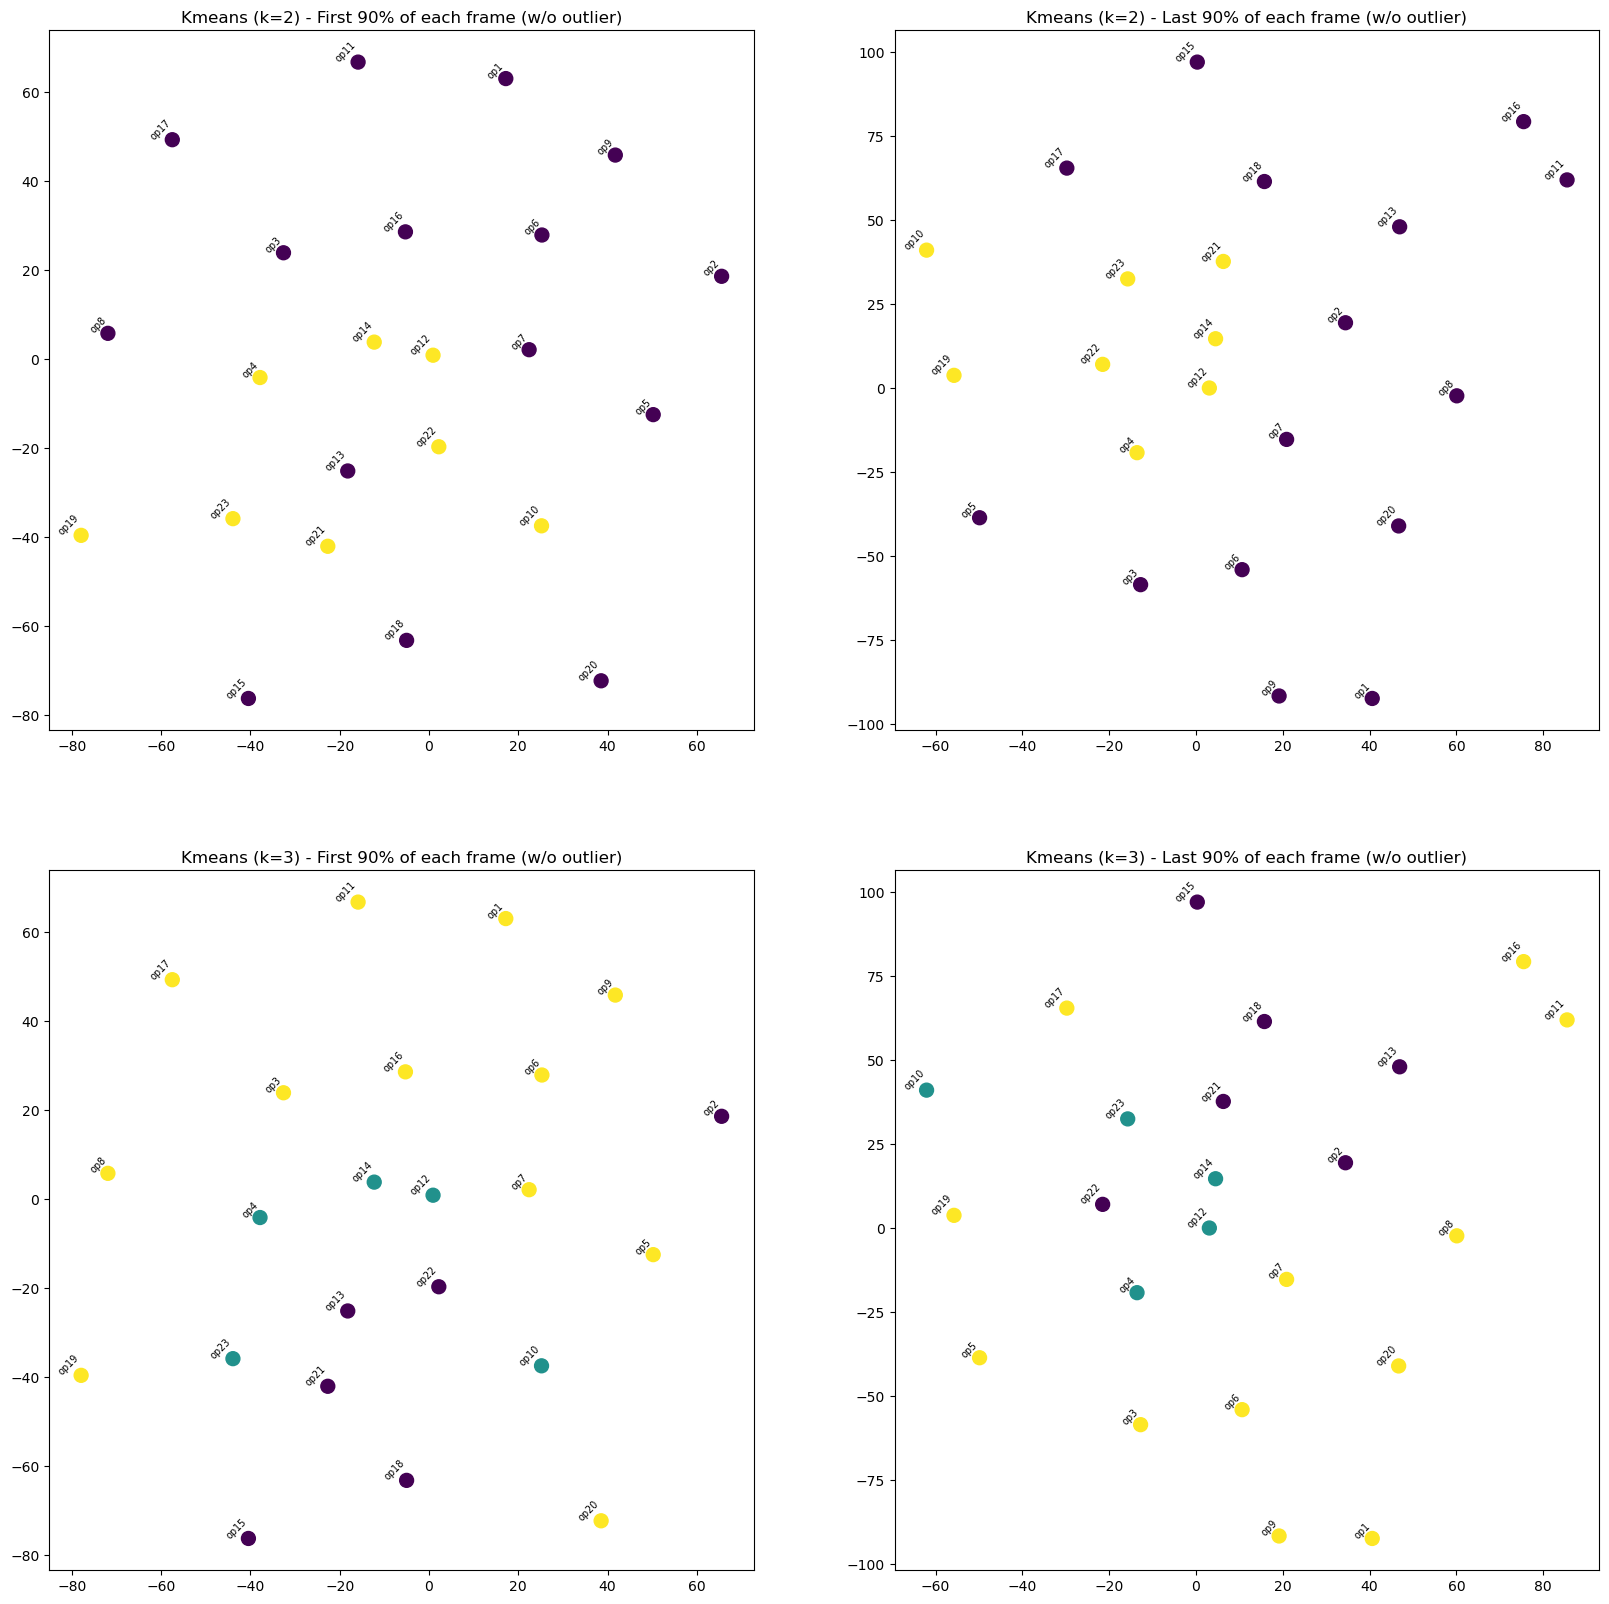

In [57]:
## kmeans 
_, first90_kmeans_k2 = kMeans_nDTW(first90_ops)
_, last90_kmeans_k2= kMeans_nDTW(last90_ops)

_, first90_kmeans_k3 = kMeans_nDTW(first90_ops , k=3)
_, last90_kmeans_k3= kMeans_nDTW(last90_ops, k=3)

print(f'ARI K2 : {adjusted_rand_score(first90_kmeans_k2, last90_kmeans_k2)}')
print(f'ARI K3 : {adjusted_rand_score(first90_kmeans_k3, last90_kmeans_k3)}')


fig, axes = plt.subplots(2, 2, figsize=(20, 20))
ax1, ax2, ax3, ax4 = axes.flatten()

ax1.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_kmeans_k2, s=100)

for i, op in enumerate(newOpLabels):
    ax1.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=first90_kmeans_k2, s=100)

for i, op in enumerate(newOpLabels):
    ax2.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    
ax3.scatter(first90_embedding[:, 0],first90_embedding[:,1], c=first90_kmeans_k3, s=100)

for i, op in enumerate(newOpLabels):
    ax3.annotate(op, (first90_embedding[i, 0], first90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax4.scatter(last90_embedding[:, 0],last90_embedding[:,1], c=first90_kmeans_k3, s=100)

for i, op in enumerate(newOpLabels):
    ax4.annotate(op, (last90_embedding[i, 0], last90_embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax1.set_title(f"Kmeans (k=2) - First 90% of each frame (w/o outlier)")
ax2.set_title(f"Kmeans (k=2) - Last 90% of each frame (w/o outlier)")
ax3.set_title(f"Kmeans (k=3) - First 90% of each frame (w/o outlier)")
ax4.set_title(f"Kmeans (k=3) - Last 90% of each frame (w/o outlier)")

plt.show()

### Comparing operation chunks

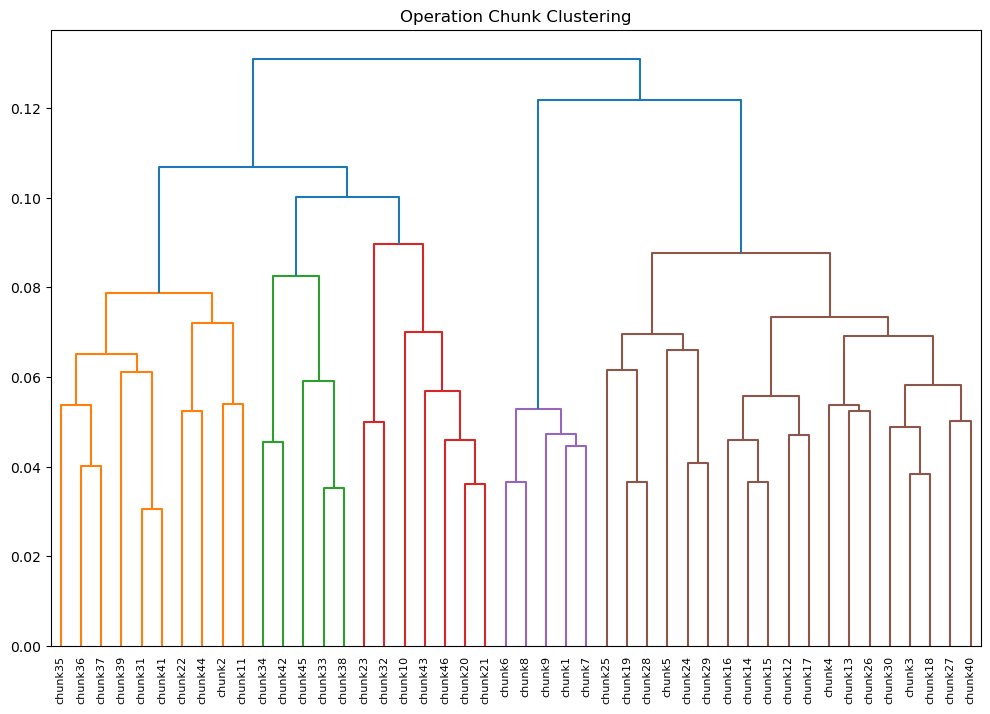

In [58]:
chunkLabels = [f"chunk{i}" for i in range(1,47)]

chunk_matrix = n_dtw(operation_chunks)
chunk_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(chunk_matrix)


##hierachical clustering on first and last 90% frames of each operation
condensedDist = squareform(chunk_matrix)
x = linkage(condensedDist, method='complete') #linkage matrix


plt.figure(figsize=(12, 8))
dendrogram(x, labels = chunkLabels)
plt.title("Operation Chunk Clustering")
plt.show()

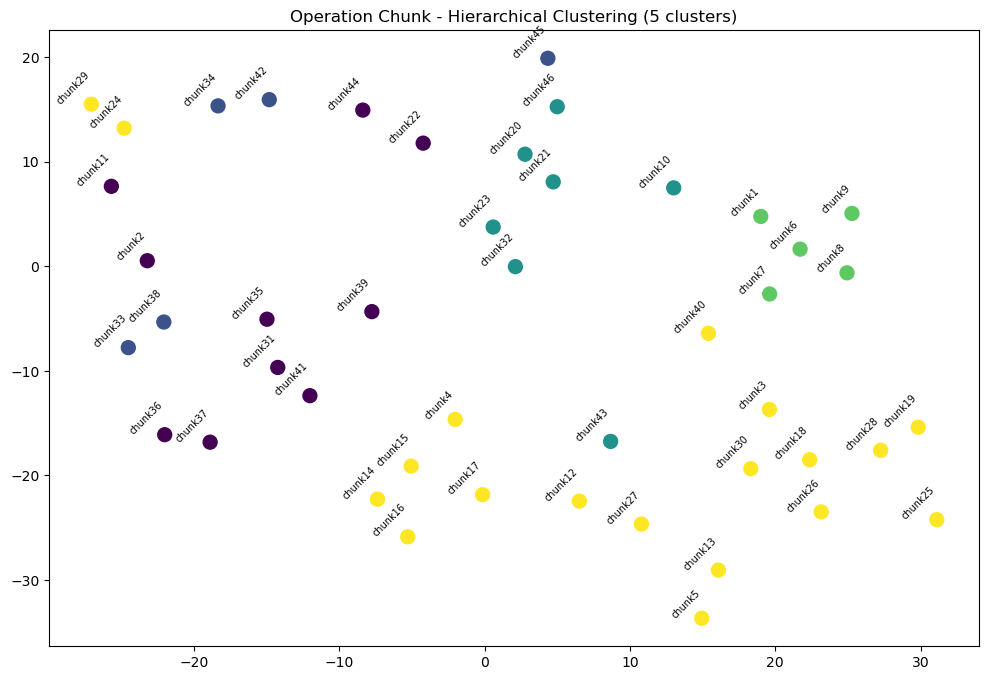

In [59]:
chunk_hierachical = fcluster(x, t=5, criterion='maxclust') 


plt.figure(figsize=(12, 8))
plt.scatter(chunk_embedding[:, 0], chunk_embedding[:, 1], 
            c=chunk_hierachical, s=100)
for i, op in enumerate(chunkLabels):
    plt.annotate(op, (chunk_embedding[i, 0], chunk_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operation Chunk - Hierarchical Clustering (5 clusters)')
plt.show()

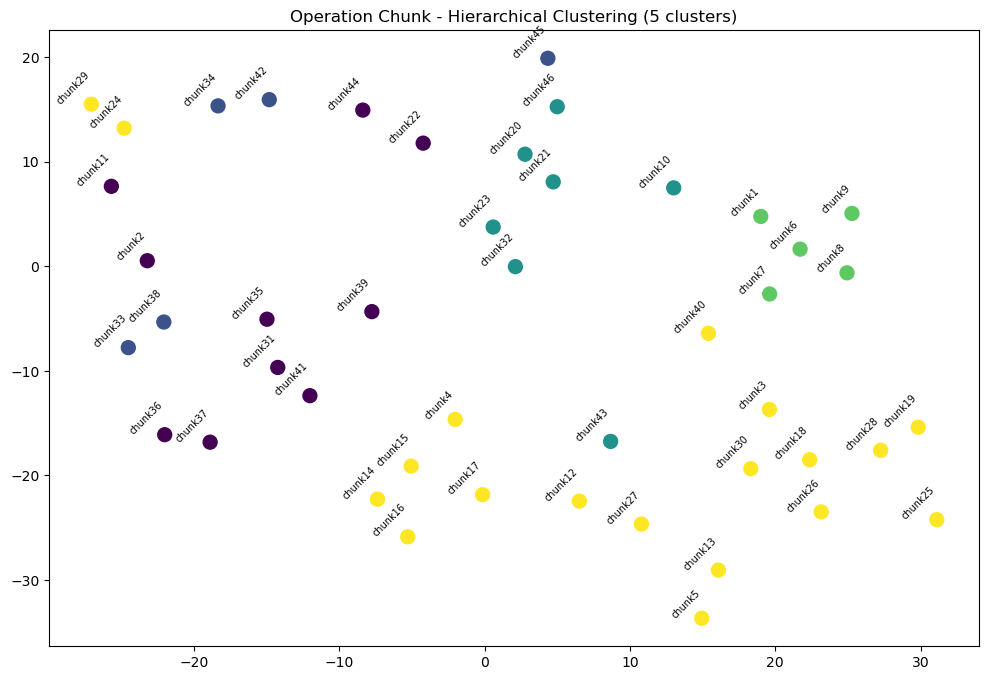

In [60]:
chunk_hierachical = fcluster(x, t=5, criterion='maxclust') 


plt.figure(figsize=(12, 8))
plt.scatter(chunk_embedding[:, 0], chunk_embedding[:, 1], 
            c=chunk_hierachical, s=100)
for i, op in enumerate(chunkLabels):
    plt.annotate(op, (chunk_embedding[i, 0], chunk_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operation Chunk - Hierarchical Clustering (5 clusters)')
plt.show()

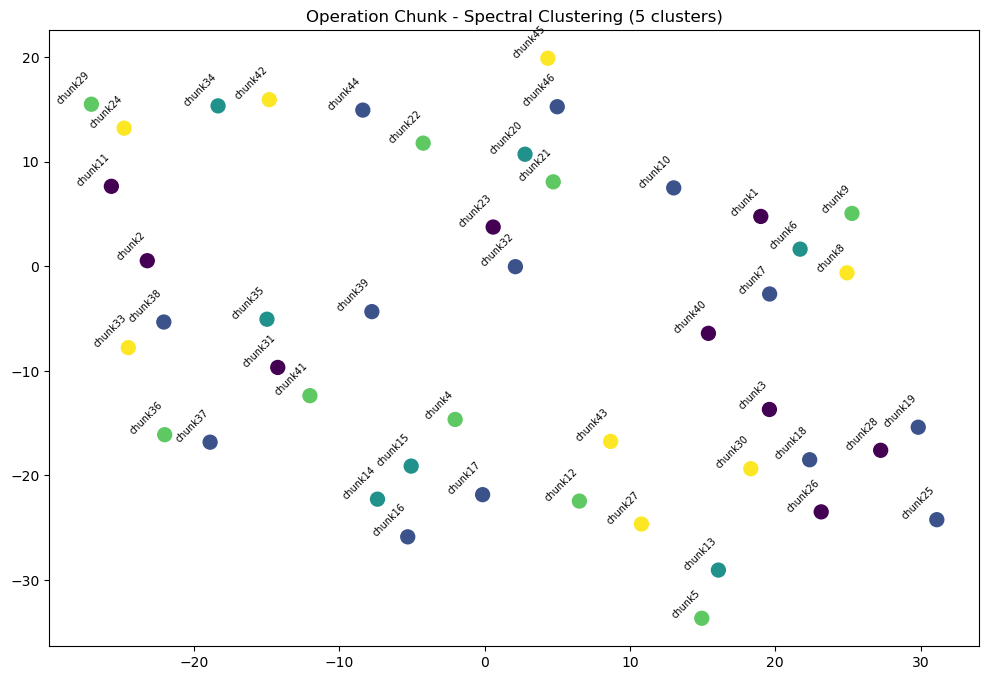

In [61]:
#spectral clustering
chunk_spectral = SpectralClustering(n_clusters=5, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(chunk_matrix).labels_

plt.figure(figsize=(12, 8))
plt.scatter(chunk_embedding[:, 0], chunk_embedding[:, 1], 
            c=chunk_spectral, s=100)

for i, op in enumerate(chunkLabels):
    plt.annotate(op, (chunk_embedding[i, 0], chunk_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operation Chunk - Spectral Clustering (5 clusters)')
plt.show()

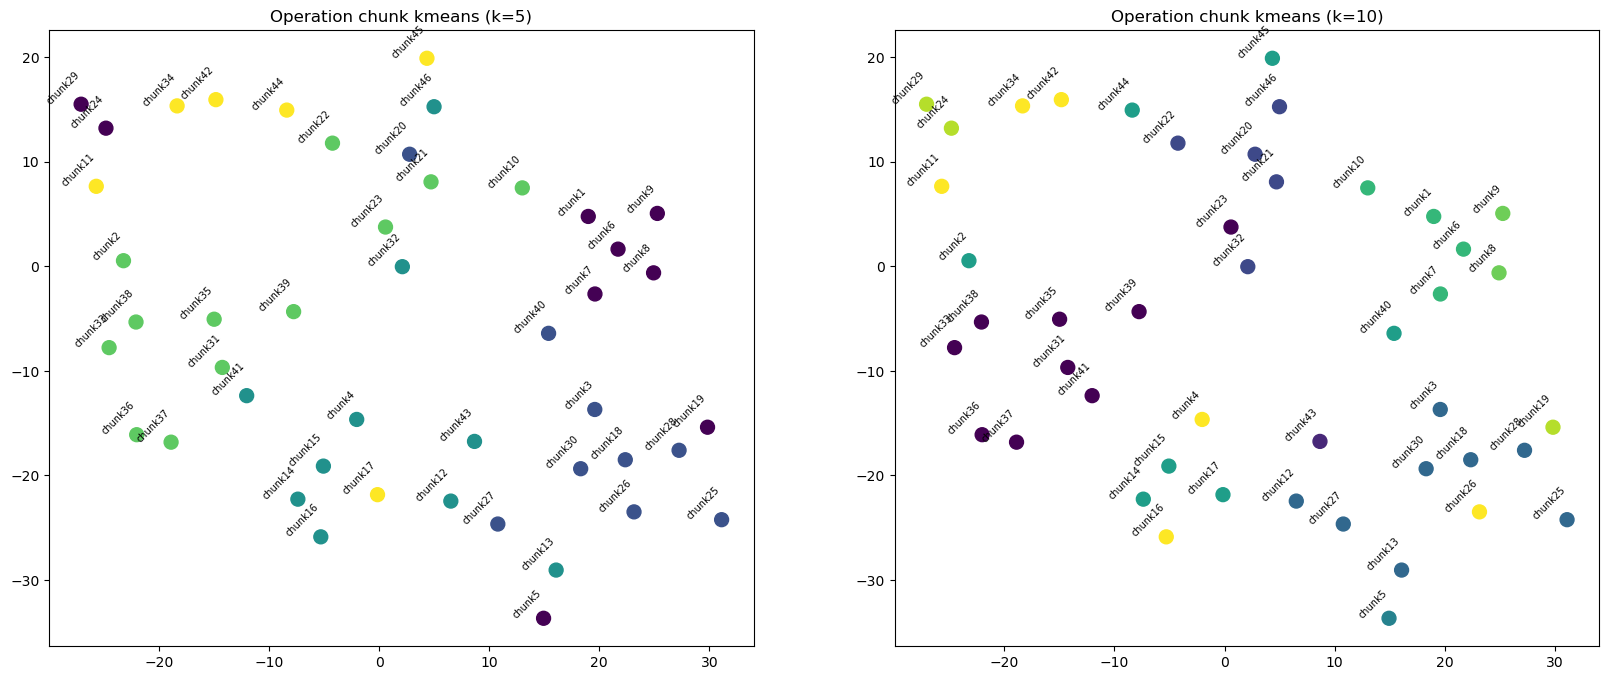

In [62]:
#k means 
_, chunk_kmeans_k5 = kMeans_nDTW(operation_chunks, k=5)
_, chunk_kmeans_k10 = kMeans_nDTW(operation_chunks , k=10)




fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(chunk_embedding[:, 0],chunk_embedding[:,1], c=chunk_kmeans_k5, s=100)

for i, op in enumerate(chunkLabels):
    ax1.annotate(op, (chunk_embedding[i, 0], chunk_embedding[i, 1]), fontsize=7, ha='right', rotation=45)

ax2.scatter(chunk_embedding[:, 0],chunk_embedding[:,1], c=chunk_kmeans_k10, s=100)

for i, op in enumerate(chunkLabels):
    ax2.annotate(op, (chunk_embedding[i, 0], chunk_embedding[i, 1]), fontsize=7, ha='right', rotation=45)

ax1.set_title("Operation chunk kmeans (k=5)")
ax2.set_title("Operation chunk kmeans (k=10)")

plt.show()

In [63]:
#comparing to if chunks clustered per operation 
op1 = [1,1]
op2 = [2,2,2]
op3 = [3,3]
op4 = [4,4]
op5 = [5 for i in range(10)]
op6 = [6,6]
op7 = [7 for i in range(9)]
op8 = [8 for i in range(7)]
op9 = [9 for i in range(4)]
op10 = [10 for i in range(5)] 
per_op_chunks = op1 + op2 + op3 + op4 + op5 + op6 + op7 + op8 + op9 + op10 


chunk_spectral10 = SpectralClustering(n_clusters=10, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(chunk_matrix).labels_
chunk_hierachical10 = fcluster(x, t=10, criterion='maxclust') 


print(f'ARI spectral: {adjusted_rand_score(per_op_chunks, chunk_spectral10)}')
print(f'ARI hiearchical: {adjusted_rand_score(per_op_chunks, chunk_hierachical10)}')
print(f'ARI kmeans: {adjusted_rand_score(per_op_chunks, chunk_kmeans_k10)}')


ARI spectral: 0.007856507560035577
ARI hiearchical: 0.20034767492394612
ARI kmeans: 0.15283461925528347


In [64]:
#comparing chunk labels 

print(f'ARI spectral v hierachical: {adjusted_rand_score(chunk_spectral,chunk_hierachical)}')
print(f'ARI spectral v kmeans: {adjusted_rand_score(chunk_spectral, chunk_kmeans_k5)}')
print(f'ARI kmeans vs hierachical: {adjusted_rand_score(chunk_kmeans_k5, chunk_hierachical)}')

ARI spectral v hierachical: -0.03591272310197634
ARI spectral v kmeans: -0.012900078592915797
ARI kmeans vs hierachical: 0.23458565960455421


## Clustering with operations over 10 frames


In [109]:
operations_over10=[]
for operation in operations:
    if len(operation)>=10:
        operations_over10.append(operation)

In [110]:
over10_matrix = n_dtw(operations_over10)
over10_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(over10_matrix)


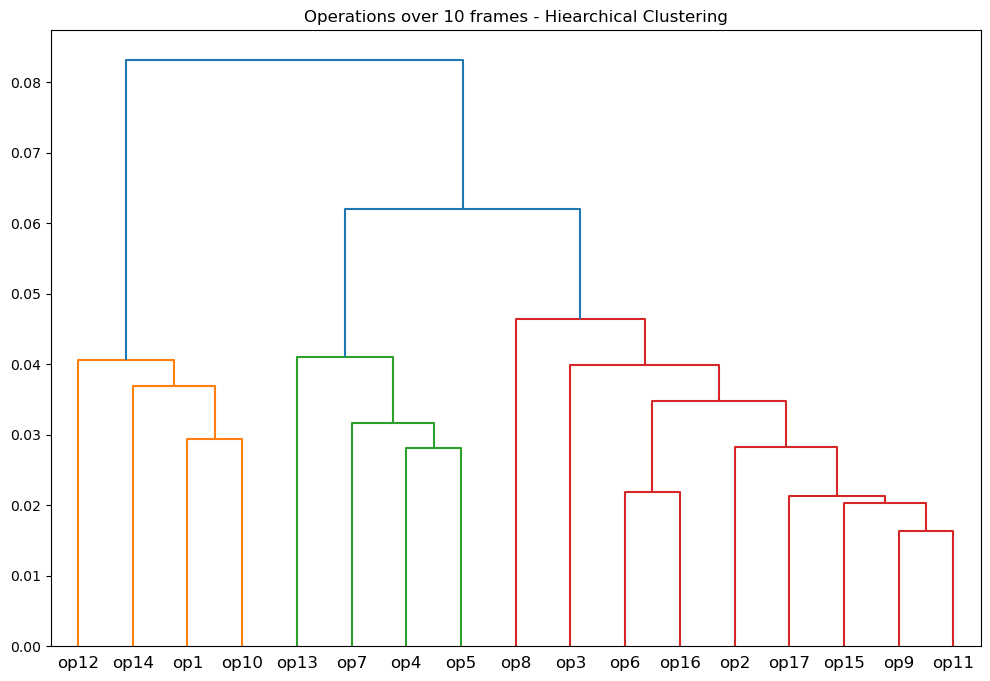

In [111]:
#dendrogram
over10_labels = [f"op{i}" for i in range(1, 18)]
condensedDist = squareform(over10_matrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix


plt.figure(figsize=(12, 8))
dendrogram(x, labels = over10_labels)
plt.title("Operations over 10 frames - Hiearchical Clustering")
plt.show()

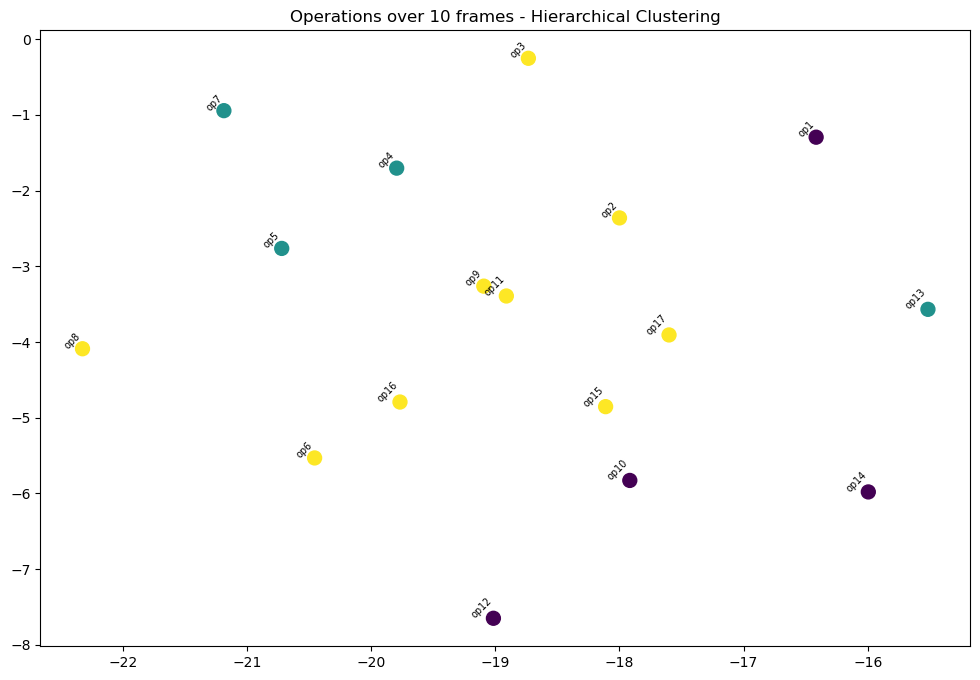

In [112]:
#plotting clusters 
over10_hierachical_k2 = fcluster(x, t=2, criterion='maxclust') 
over10_hierachical = fcluster(x, t=3, criterion='maxclust') 


plt.figure(figsize=(12, 8))
plt.scatter(over10_embedding[:, 0], over10_embedding[:, 1], 
            c=over10_hierachical, s=100)
for i, op in enumerate(over10_labels):
    plt.annotate(op, (over10_embedding[i, 0], over10_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations over 10 frames - Hierarchical Clustering')
plt.show()

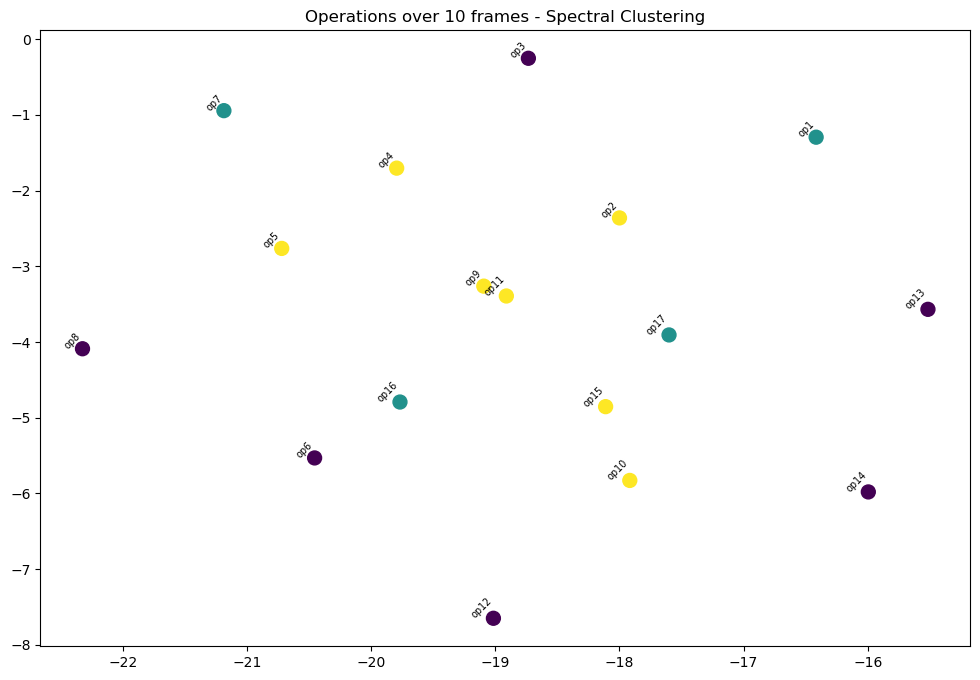

In [ ]:

over10_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(over10_matrix).labels_

plt.figure(figsize=(12, 8))
plt.scatter(over10_embedding[:, 0], over10_embedding[:, 1], 
            c=over10_spectral, s=100)

for i, op in enumerate(over10_labels):
    plt.annotate(op, (over10_embedding[i, 0], over10_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations over 10 frames - Spectral Clustering')
plt.show()

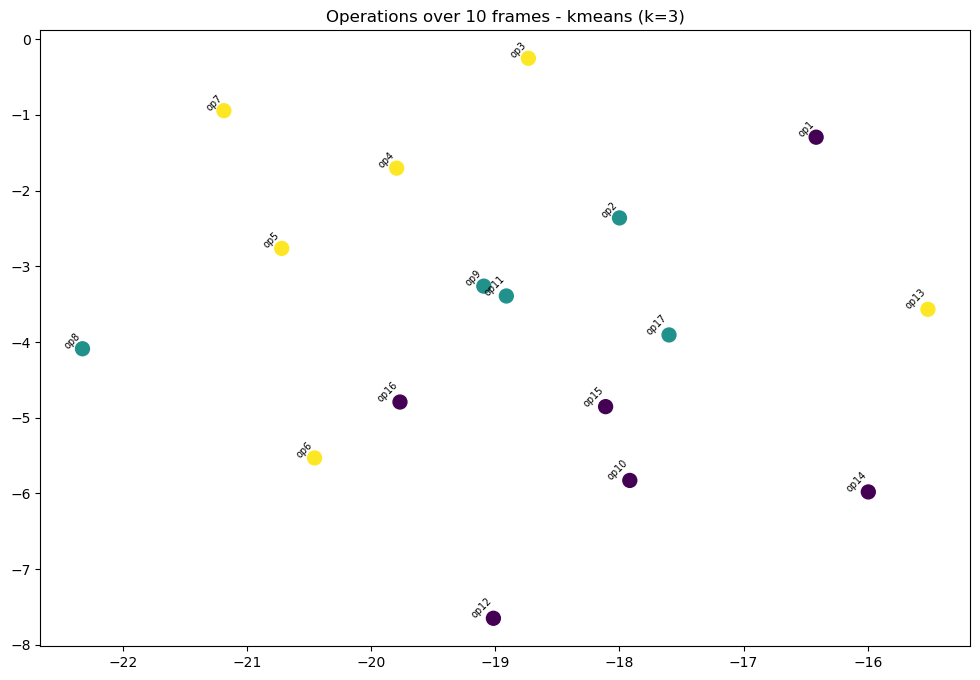

In [117]:
_, over10_kmeans = kMeans_nDTW(operations_over10, k=3)
_, over10_kmeans_k2 = kMeans_nDTW(operations_over10)
plt.figure(figsize=(12, 8))
plt.scatter(over10_embedding[:, 0], over10_embedding[:, 1], 
            c=over10_kmeans, s=100)

for i, op in enumerate(over10_labels):
    plt.annotate(op, (over10_embedding[i, 0], over10_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations over 10 frames - kmeans (k=3)')
plt.show()

In [71]:
#cluster agreement
# print(f'ARI: {adjusted_rand_score(over10_hierachical, over10_spectral)}')
print(f'ARI: {adjusted_rand_score(over10_hierachical, over10_kmeans)}')
# print(f'ARI: {adjusted_rand_score(over10_kmeans, over10_spectral)}')


ARI: 0.03608247422680412


## Clustering with num clinicians as only feature

In [72]:
try:
    with open('clinicians_per_operation.pkl', 'rb') as f:
        clinicians = pickle.load(f)
except:
    print("Error")

In [73]:
#ndtw
clinicians_matrix = n_dtw(clinicians)

#embedding
clinicians_embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(clinicians_matrix)


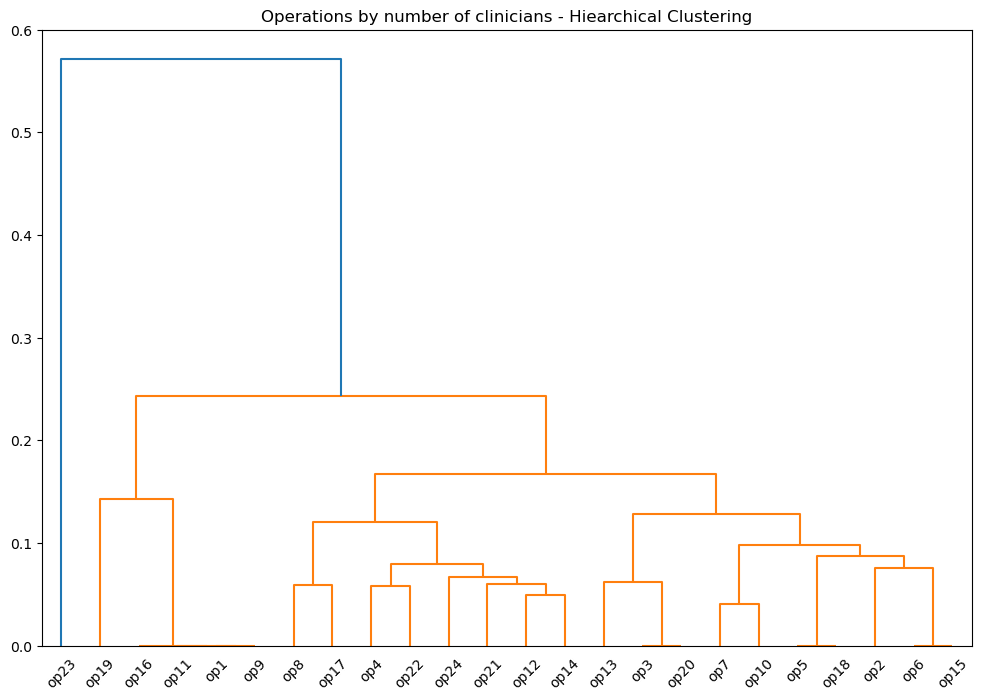

In [74]:
#dendrogram
condensedDist = squareform(clinicians_matrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix


plt.figure(figsize=(12, 8))
dendrogram(x, labels = opLabels)
plt.title("Operations by number of clinicians - Hiearchical Clustering")
plt.show()




operation 23 is once more an outlier, likely because of num clincians. Thus will look further into num clincians per operations

In [75]:
for i, op in enumerate(clinicians, start = 1):
    print(np.mean(op))

1.0
1.5217391304347827
1.25
1.6363636363636365
1.3
1.0476190476190477
1.1428571428571428
1.3333333333333333
1.0
1.6153846153846154
1.0
2.0952380952380953
1.2173913043478262
1.6288659793814433
1.1666666666666667
1.0
1.4545454545454546
1.2727272727272727
1.25
1.25
2.2285714285714286
2.097560975609756
2.6
1.830188679245283


In [76]:
mean_per_op = [np.mean(op) for op in clinicians]
print(np.mean(mean_per_op))

1.4557938650969078


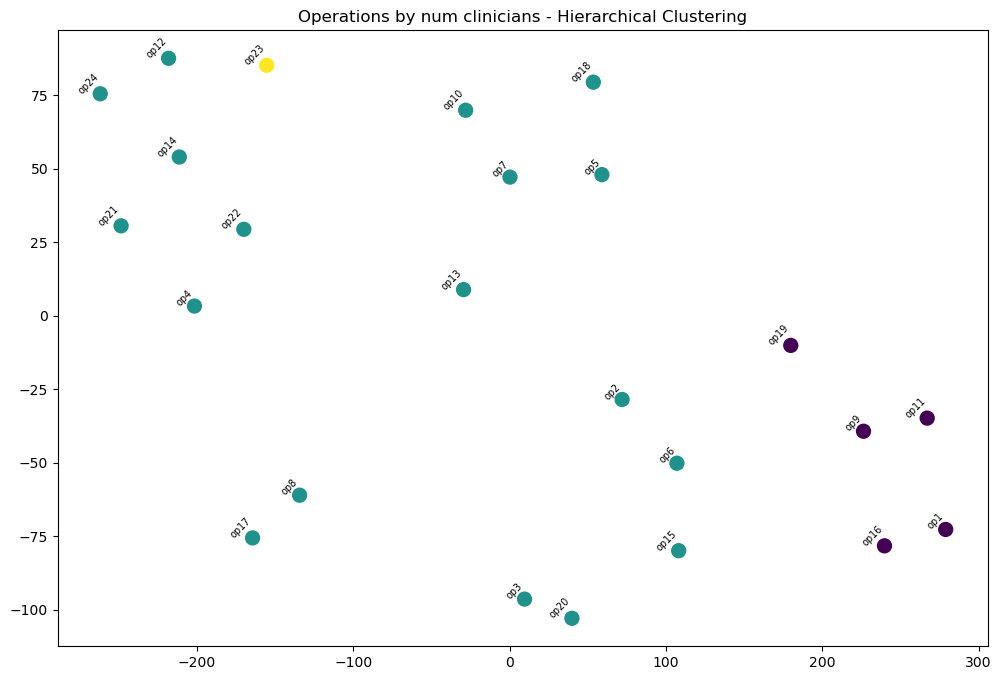

In [77]:
#plotting clusters 
clinicians_hierachical = fcluster(x, t=3, criterion='maxclust') 


plt.figure(figsize=(12, 8))
plt.scatter(clinicians_embedding[:, 0], clinicians_embedding[:, 1], 
            c=clinicians_hierachical, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (clinicians_embedding[i, 0], clinicians_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations by num clinicians - Hierarchical Clustering')
plt.show()

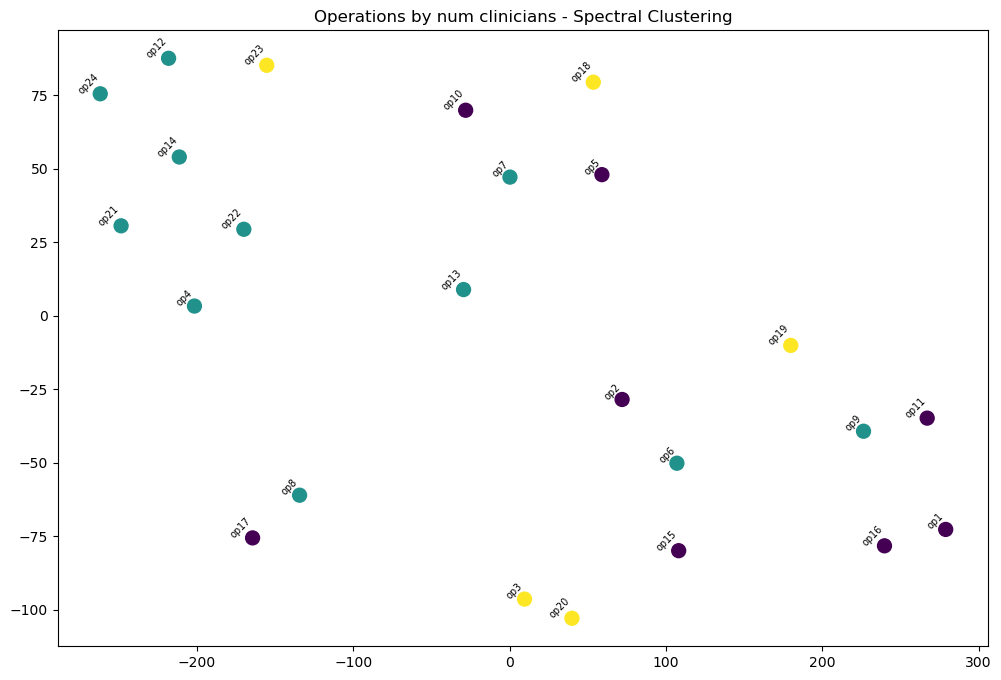

In [78]:
#spectral clustering

clinicians_spectral = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(clinicians_matrix).labels_

plt.figure(figsize=(12, 8))
plt.scatter(clinicians_embedding[:, 0], clinicians_embedding[:, 1], 
            c=clinicians_spectral, s=100)

for i, op in enumerate(opLabels):
    plt.annotate(op, (clinicians_embedding[i, 0], clinicians_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations by num clinicians - Spectral Clustering')
plt.show()

In [88]:
##kmeans
from DBA import*

def assign_centroids_uni(X, centroids, cost_mat, delta_mat):
    labels = [] 
    for x in X:
        dists = [] #distance to each centroid
        for centroid in centroids:
            dists.append(squared_DTW(x, centroid, cost_mat, delta_mat))
        
        labels.append(np.argmin(dists))

    labels = np.array(labels)
    return labels


def update_centroids_uni(X, k, labels):
    new_centroids = []
    for i in range(k):
        series_in_cluster = []
        for x, l in zip(X, labels):
            if l == i:
                series_in_cluster.append(x)
        
        new_centroids.append(performDBA(series_in_cluster))

    return new_centroids

def compute_inertia_uni(X, N, labels, centroids, cost_mat, delta_mat):
    inertia = 0
    for i in range(N):
        inertia += squared_DTW(X[i], centroids[labels[i]], cost_mat, delta_mat)

    return inertia


def kMeans_nDTW_uni(X, k = 2, n_runs = 10, max_iter=100, random_state = None):
    '''
    X: operations
    k: # clusters
    n_runs: number of times we run algorithm before choosing best result
    max_iter: number of mean in kmeans algorithm
    random_state: param used to init random number generator


    return:
        - clustering labels
        - inertia
    '''

    rng = np.random.RandomState(random_state)
    N = len(X)
    bestInertia = np.inf
    bestLabels = None 

    #allocate matrices for NDTW computations
    max_length = max(x.shape[0] for x in X)
    cost_mat = np.zeros((max_length, max_length))
    delta_mat = np.zeros((max_length, max_length))
    path_mat = np.zeros((max_length, max_length), dtype=np.int8)



    for run in range(n_runs):

        #init centroids 
        centroid_indices = rng.choice(N, k, replace=False)
        centroids = [X[i] for i in centroid_indices]
        labels = np.zeros(N)

        for iteration in range(max_iter):
            prev_labels = labels.copy() 

            # assign each operation to nearest centroid (lowest nDTW dist)
            labels = assign_centroids_uni(X, centroids, cost_mat, delta_mat)

            #update centroid
            centroids = update_centroids_uni(X,k,labels)

            # check convergence
            if np.allclose(labels, prev_labels):
                break


        #compute inertia
        inertia = compute_inertia_uni(X, N, labels, centroids, cost_mat, delta_mat)


        #updating best inertia 
        if inertia < bestInertia:
            bestInertia = inertia
            bestLabel = labels
    
    return bestInertia, bestLabel

In [94]:
_, clinicians_kmeans = kMeans_nDTW_uni(clinicians, k=3)


In [90]:
#cluster agreement
print(f'ARI: {adjusted_rand_score(clinicians_hierachical, clinicians_spectral)}')


ARI: 0.083147404432545


In [95]:
print(f'ARI: {adjusted_rand_score(clinicians_hierachical, clinicians_kmeans)}')

ARI: -0.011956001912960305


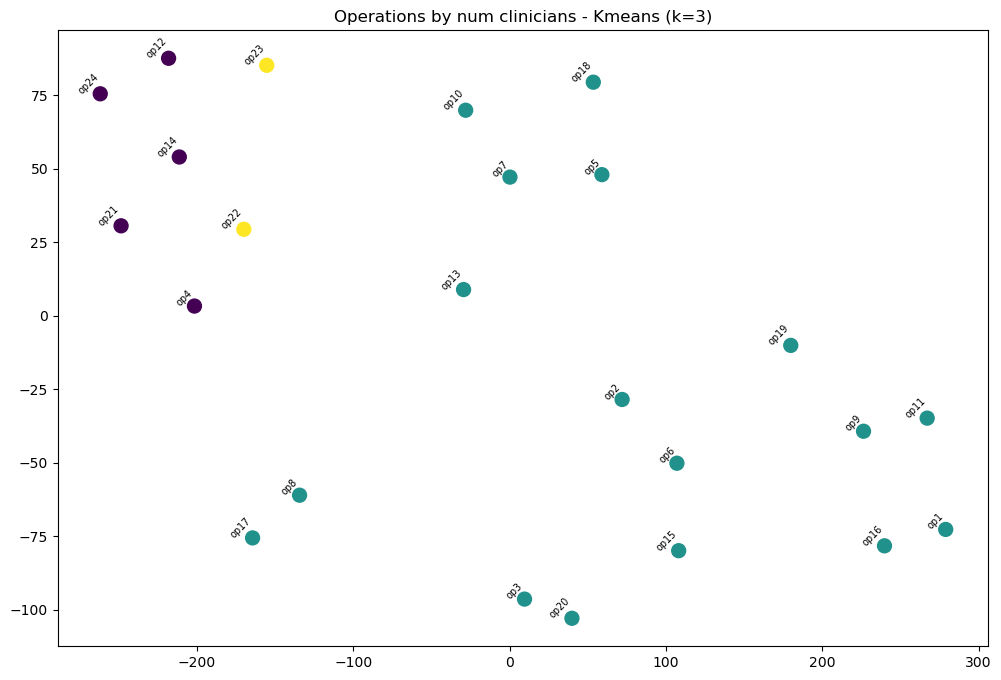

In [96]:
plt.figure(figsize=(12, 8))
plt.scatter(clinicians_embedding[:, 0], clinicians_embedding[:, 1], 
            c=clinicians_kmeans, s=100)

for i, op in enumerate(opLabels):
    plt.annotate(op, (clinicians_embedding[i, 0], clinicians_embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Operations by num clinicians - Kmeans (k=3)')
plt.show()

## Comparing results against manual annotations 

In [97]:
orientation_labels = [1, 1, 1, 2, 1, 2, 1, 3, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1] # 1 if down, 2 if up, 3 if side
machinery_labels = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1] # 1 if c machine is present, 0 otherwise

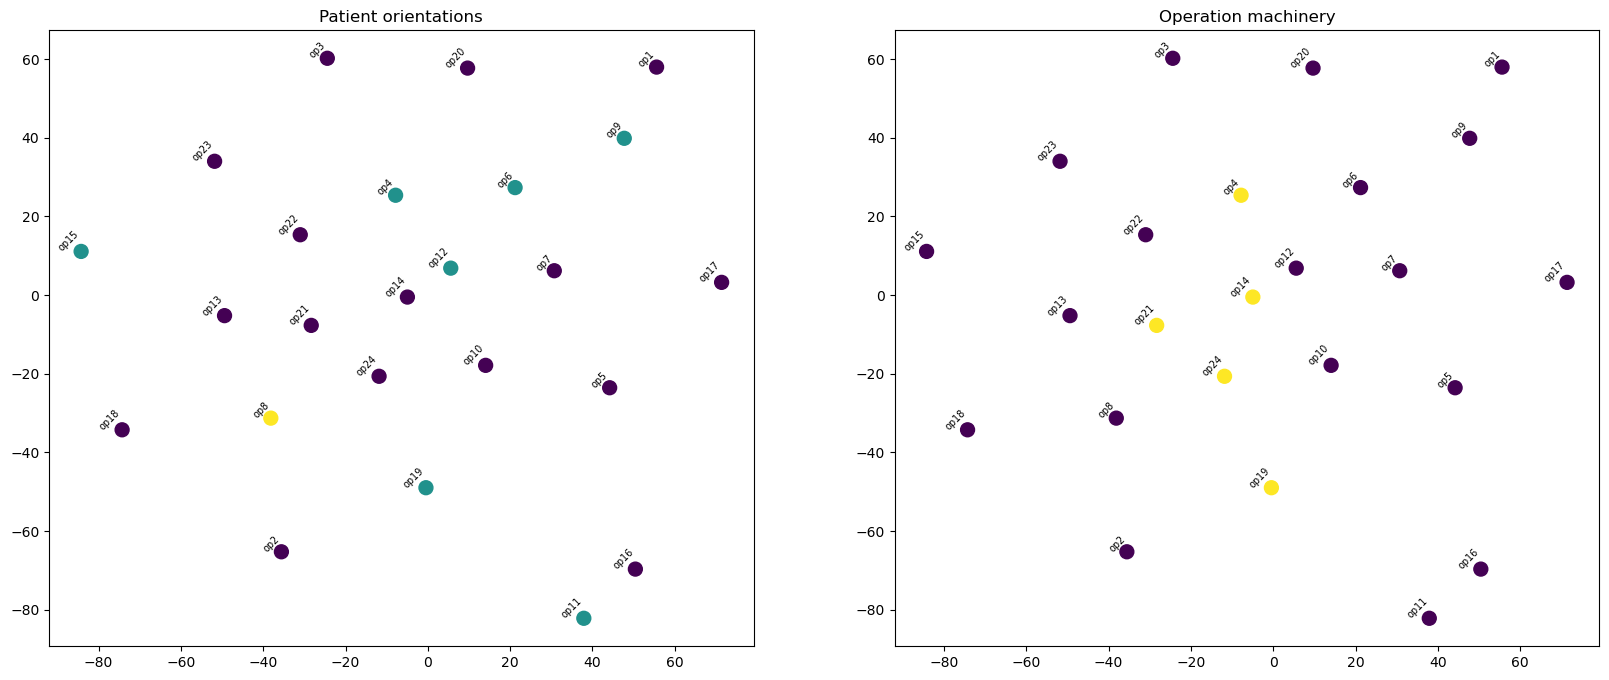

In [98]:
#plotting labels 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(embedding[:, 0],embedding[:,1], c=orientation_labels, s=100)

for i, op in enumerate(opLabels):
    ax1.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)


ax2.scatter(embedding[:, 0],embedding[:,1], c=machinery_labels, s=100)

for i, op in enumerate(opLabels):
    ax2.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
    


ax1.set_title(f"Patient orientations")
ax2.set_title(f"Operation machinery")

plt.show()

In [99]:
#Machinery labels vs all 2 cluster labels ; Patient Orientations vs all 3 cluster labels

labels_k3 = [hierachical_labels, kmed_labels_k3, spec_clustering_labels_k3, clinicians_hierachical, clinicians_spectral, nKmeans_k3]

labels_k2 = [spec_clustering_labels, kmed_labels_k2, nKmeans_k2] 

In [102]:
for i, label in enumerate(labels_k3):    
    print(f'ARI: {adjusted_rand_score(orientation_labels, labels_k3[i])}')


ARI: -0.05514532600157109
ARI: -0.09885274241709885
ARI: -0.02046555225745977
ARI: 0.06879645737782698
ARI: -0.06491475050836853
ARI: -0.05514532600157109


In [103]:
for i, label in enumerate(labels_k2): 
    print(f'ARI: {adjusted_rand_score(machinery_labels, labels_k2[i])}')


ARI: 0.08281842255568825
ARI: 0.18231195479234102
ARI: 0.22612804403136197


### Comparing operations over 10 frames to annotations

In [ ]:
labels_over10_k2 = [over10_hierachical_k2, over10_kmeans_k2]
labels_over10_k3 = [over10_spectral, over10_hierachical, over10_kmeans]

orientation_labels_over10 = [1X, 1, 1X, 2, 1, 2, 1, 3, 2, 1, 2, 2, 1, 1, 2, 1, 1, 1, 2, 1, 1, 1, 1, 1] # 1 if down, 2 if up, 3 if side
machinery_labels_over10 = [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1] # 1 if c machine is present, 0 otherwise